In [ ]:
# - Librairies -----
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from nucleo.io.reading import reading_all_parquet


# - Getting the data -----
# root_fact = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-05-21"
# root_fact = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-09-17"
root_fact = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026"


df_fact = reading_all_parquet(root_fact)
df_fact.group_by(["mode", "land", "l", "alphar", "Kp"])
print(df_fact)

COLUMNS = [
    'algo', 'fact', 'mode', 'dstr', 
    'land', 's', 'l', 'bpmin', 
    'mu', 'theta', 'alphaf', 
    'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 
    'alphar', 'krel', 'Kp', 'Kz'
]

# Passive

In [3]:
# - Data -----
df_passive = df_fact.filter(pl.col("mode") == "passfull")
print(df_passive)
print(df_passive.columns)

shape: (14_256, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ f64      ┆ f64      ┆ f64   │
╞══════╪══════╪══════════╪═══════╪═══╪═══════╪══════════╪══════════╪═══════╡
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 90.5  ┆ 9.545179 ┆ 6.897919 ┆ 1.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 90.5  ┆ 9.646909 ┆ 6.88635  ┆ 1.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 90.5  ┆ 5.275333 ┆ 3.847067 ┆ 1.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 90.5  ┆ 5.26464  ┆ 3.83288  ┆ 1.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 90.5  ┆ 0.998078 ┆ 0.836535 ┆ 0.5   │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …     ┆ …        ┆ …        ┆ …     │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 276.5 ┆ 5.258917 ┆ 3.819717 ┆ 1.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 272.5 ┆ 0.997484 

In [4]:
# - Data -----
df_passive = df_fact.filter(pl.col("mode") == "passfull")

# Moyenne des valeurs pour les mêmes paramètres
param_cols = [
    col for col in df_passive.columns
    if col not in ["v_mean", "vc_mean", "vf", "wf"]  # colonnes de valeurs à moyenner
]

df_passive = (
    df_passive
    .group_by(param_cols)
    .agg([
        pl.col("v_mean").mean().alias("v_mean"),
        pl.col("vc_mean").mean().alias("vc_mean"),
        pl.col("vf").mean().alias("vf"),
        pl.col("wf").mean().alias("wf"),
    ])
    .sort(["l", "alphar", "Kp"])
)

print(df_passive)
print(df_passive.columns)



shape: (14_256, 61)
┌──────┬──────┬──────────┬───────┬───┬────────────┬────────────┬────────────┬──────────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ v_mean     ┆ vc_mean    ┆ vf         ┆ wf       │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---        ┆ ---        ┆ ---        ┆ ---      │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64        ┆ f64        ┆ f64        ┆ f64      │
╞══════╪══════╪══════════╪═══════╪═══╪════════════╪════════════╪════════════╪══════════╡
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 44.709943  ┆ 158.968151 ┆ 53.678353  ┆ 0.957459 │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 3.763624   ┆ 13.302079  ┆ 13.012604  ┆ 0.767868 │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 19.915015  ┆ 70.762826  ┆ 25.896193  ┆ 0.961516 │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 2.12404    ┆ 7.551639   ┆ 11.458597  ┆ 0.523002 │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 22.276013  ┆ 79.2025    ┆ 26.981567  ┆ 0.97841  │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …          ┆ …          ┆ …          ┆ …        │
│

In [5]:
for col in COLUMNS:
    print(f"Unique values of {col} : {np.unique(df_passive[col])}")

mu          = 150
theta       = 100
rrest       = 2.0
Kz          = 0.0

df_passive = df_passive.filter(
    (pl.col("mu") == mu) &
    (pl.col("theta") == theta) &
    (pl.col("rrest") == rrest) &
    (pl.col("Kz") == Kz)
)

print(df_passive)

Unique values of algo : ['2S']
Unique values of fact : [ True]
Unique values of mode : ['passfull']
Unique values of dstr : [False]
Unique values of land : ['periodic' 'random']
Unique values of s : [35]
Unique values of l : [ 10  35 100]
Unique values of bpmin : [0]
Unique values of mu : [150 300]
Unique values of theta : [100]
Unique values of alphaf : [1.]
Unique values of alphao : [0.]
Unique values of beta : [0.]
Unique values of rcapt : [2.]
Unique values of rrest : [0.1 0.2 2. ]
Unique values of alphac : [0.67]
Unique values of alphad : [0.]
Unique values of alphar : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Unique values of krel : [1.]
Unique values of Kp : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Unique values of Kz : [0.  0.5 1. ]
shape: (792, 61)
┌──────┬──────┬──────────┬───────┬───┬────────────┬────────────┬────────────┬──────────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ v_mean     ┆ vc_mean    ┆ vf         ┆ wf       │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   

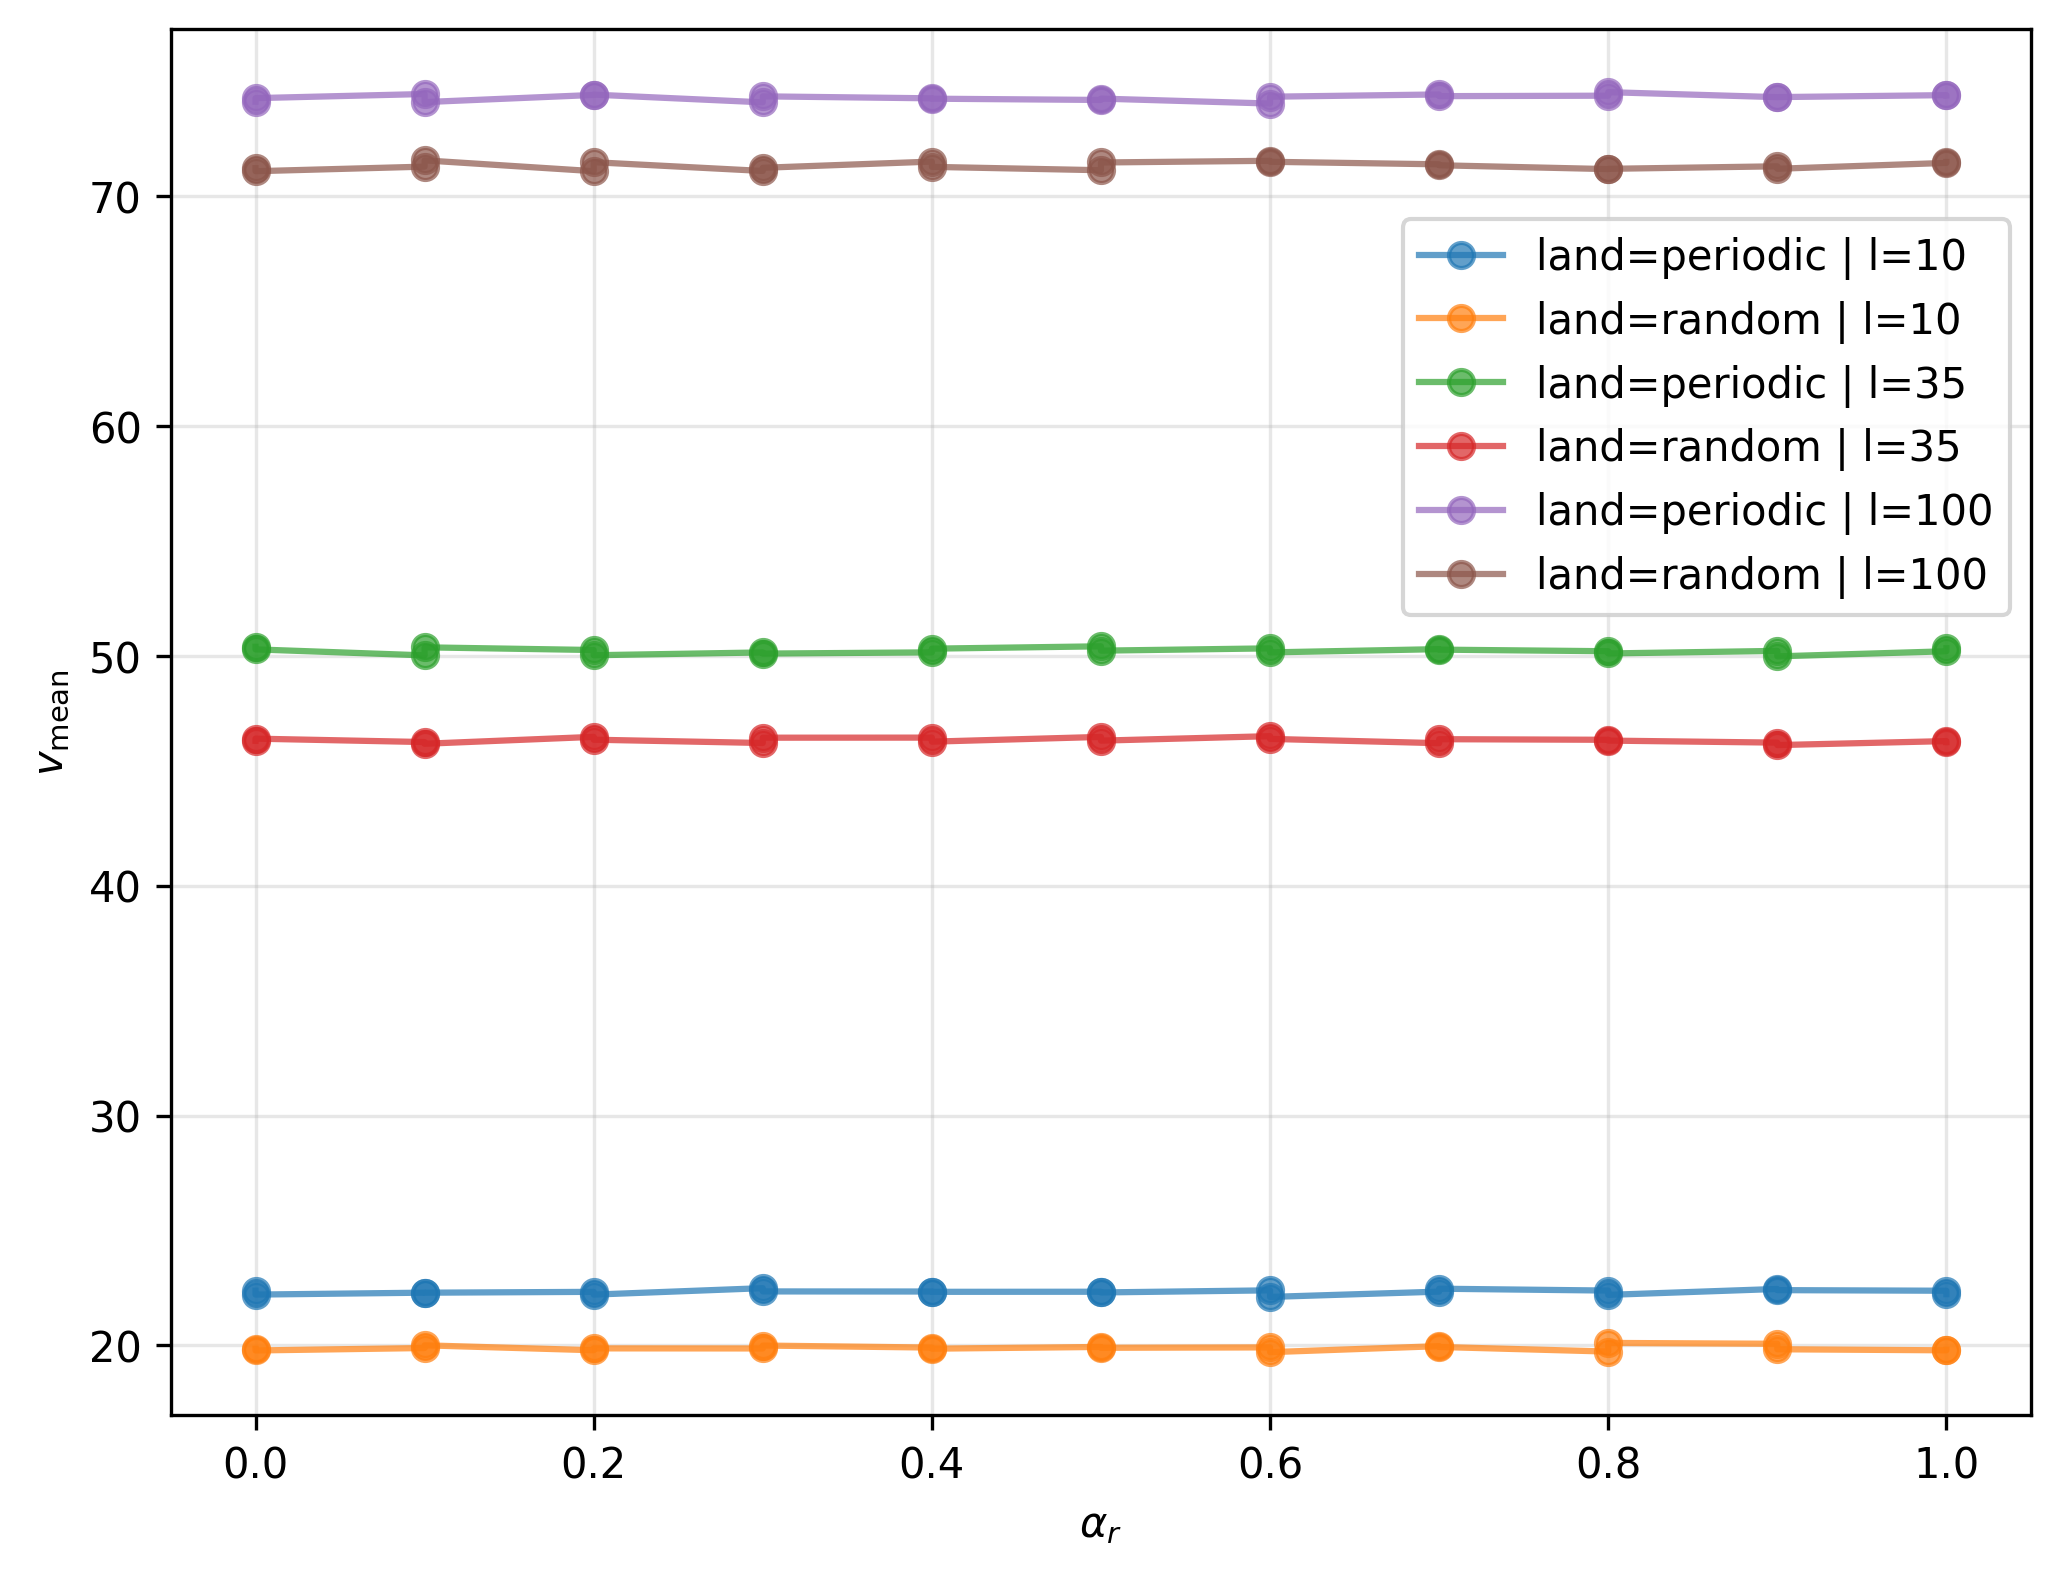

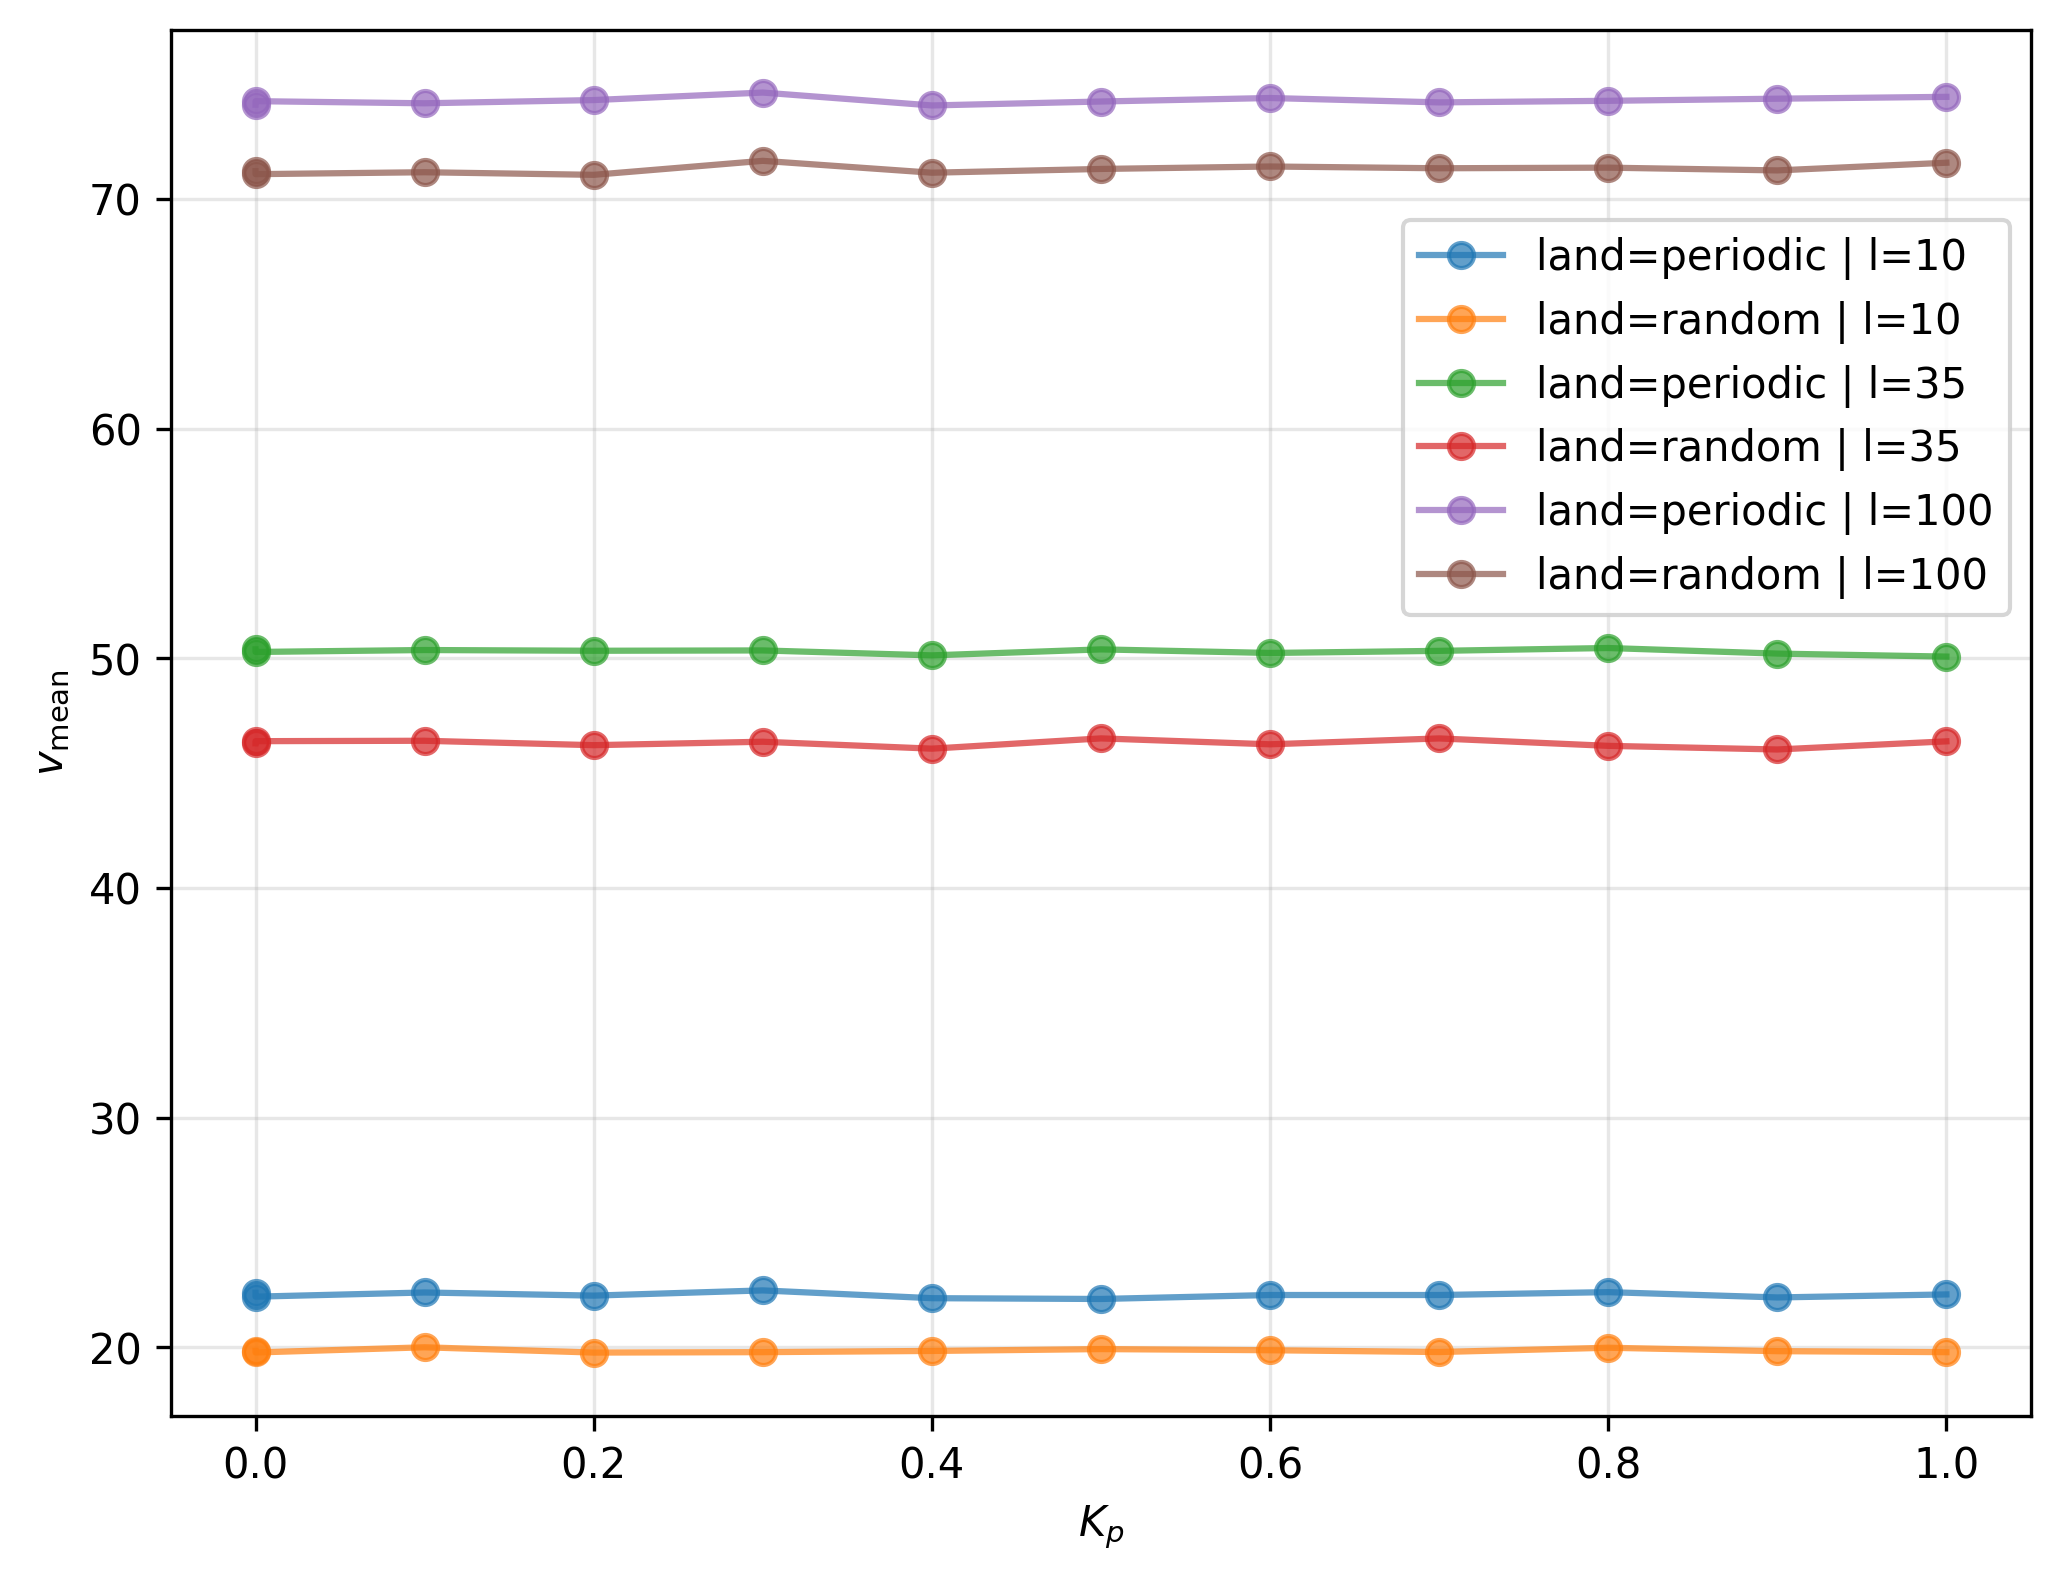

In [ ]:
plt.figure(figsize=(8,6), dpi=300)

alphar = 0
lands = ["periodic", "random"]

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:

    for land in lands :

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("alphar") == alphar) &
            (pl.col("rrest") == rrest) &
            (pl.col("l") == l)
        )

        Kp      = df_land["Kp"].to_numpy()
        v_mean  = df_land["v_mean"].to_numpy()

        plt.plot(Kp, v_mean, label=f"land={land} | l={l}", marker = "o", alpha=0.70)

# plt.title(rf"$l={l}~|~\alpha_r = {alphar}$")
plt.xlabel(r"$\alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend(
    loc="center right",
    bbox_to_anchor=(1, 0.72)
)
plt.show()


plt.figure(figsize=(8,6), dpi=300)

Kp = 0
ls = np.unique(df_passive["l"].to_numpy())

for l in ls:

    for land in lands :

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("Kp") == Kp) &
            (pl.col("l") == l)
        )

        alphar  = df_land["alphar"].to_numpy()
        v_mean  = df_land["v_mean"].to_numpy()

        plt.plot(alphar, v_mean, label=f"land={land} | l={l}", marker = "o", alpha=0.70)

# plt.title(rf"$l={l}~|~K_p = {Kp}$")
plt.xlabel(r"$K_p$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend(
    loc="center right",
    bbox_to_anchor=(1, 0.72)
)
plt.show()

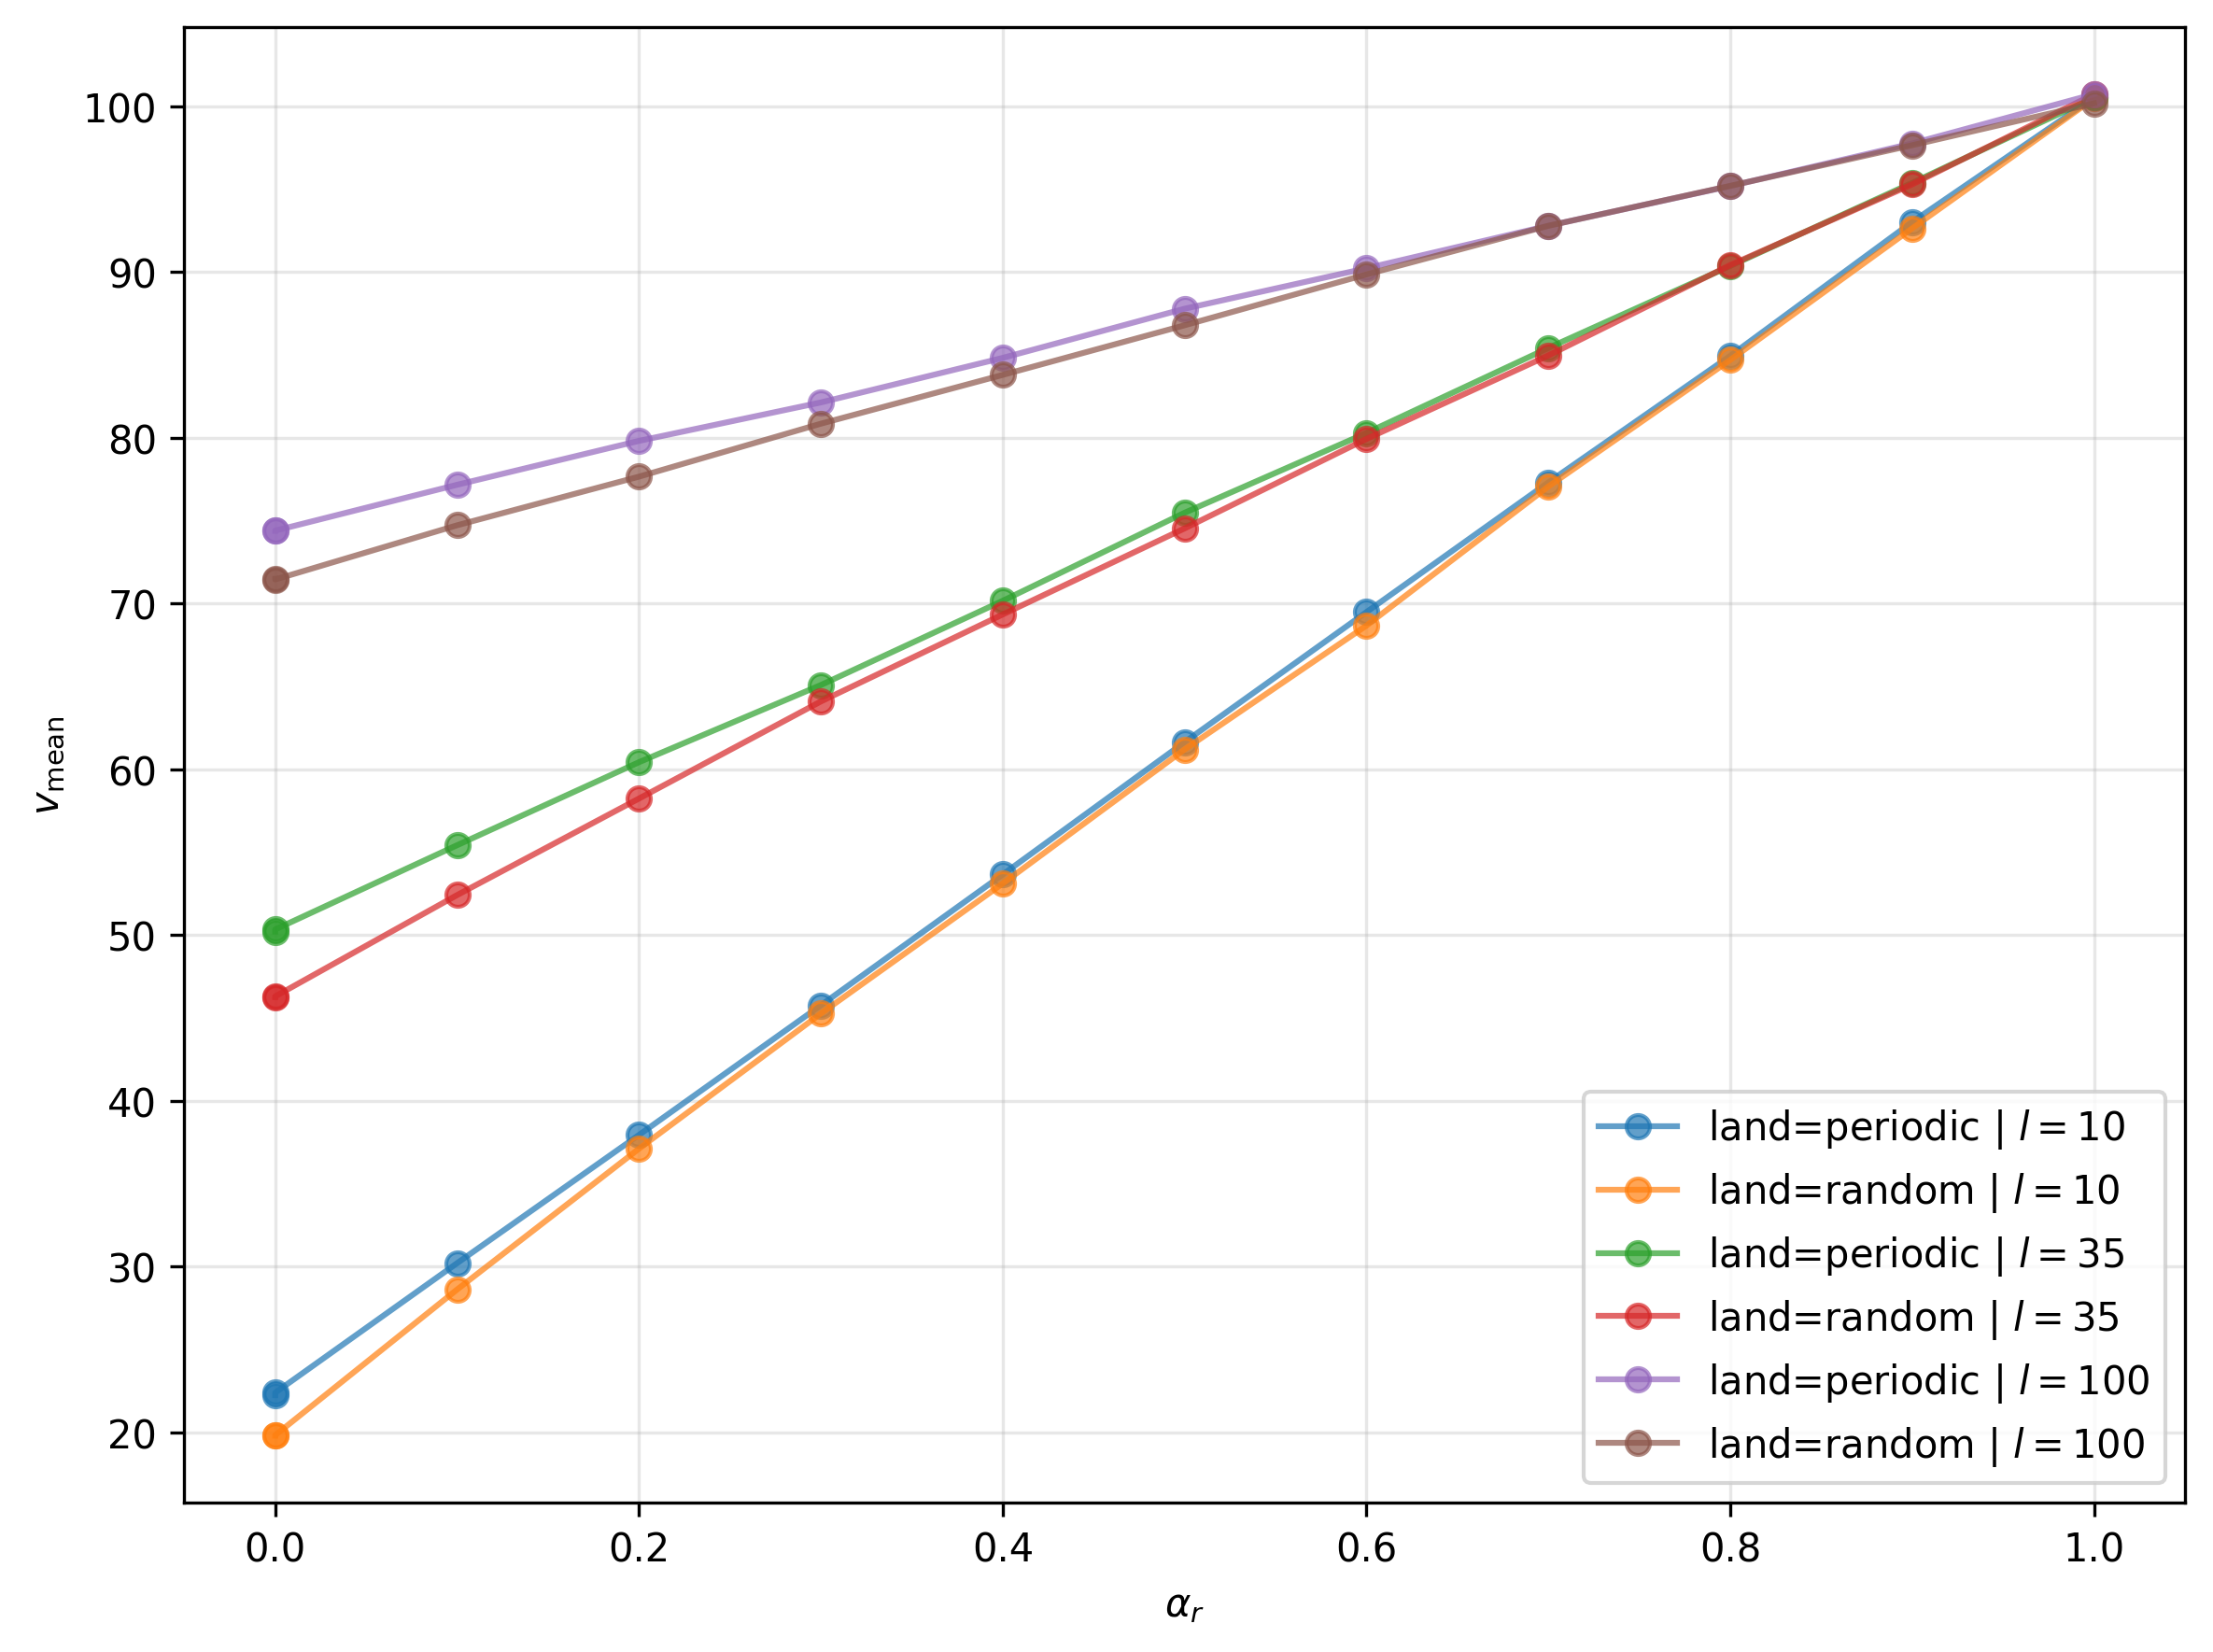

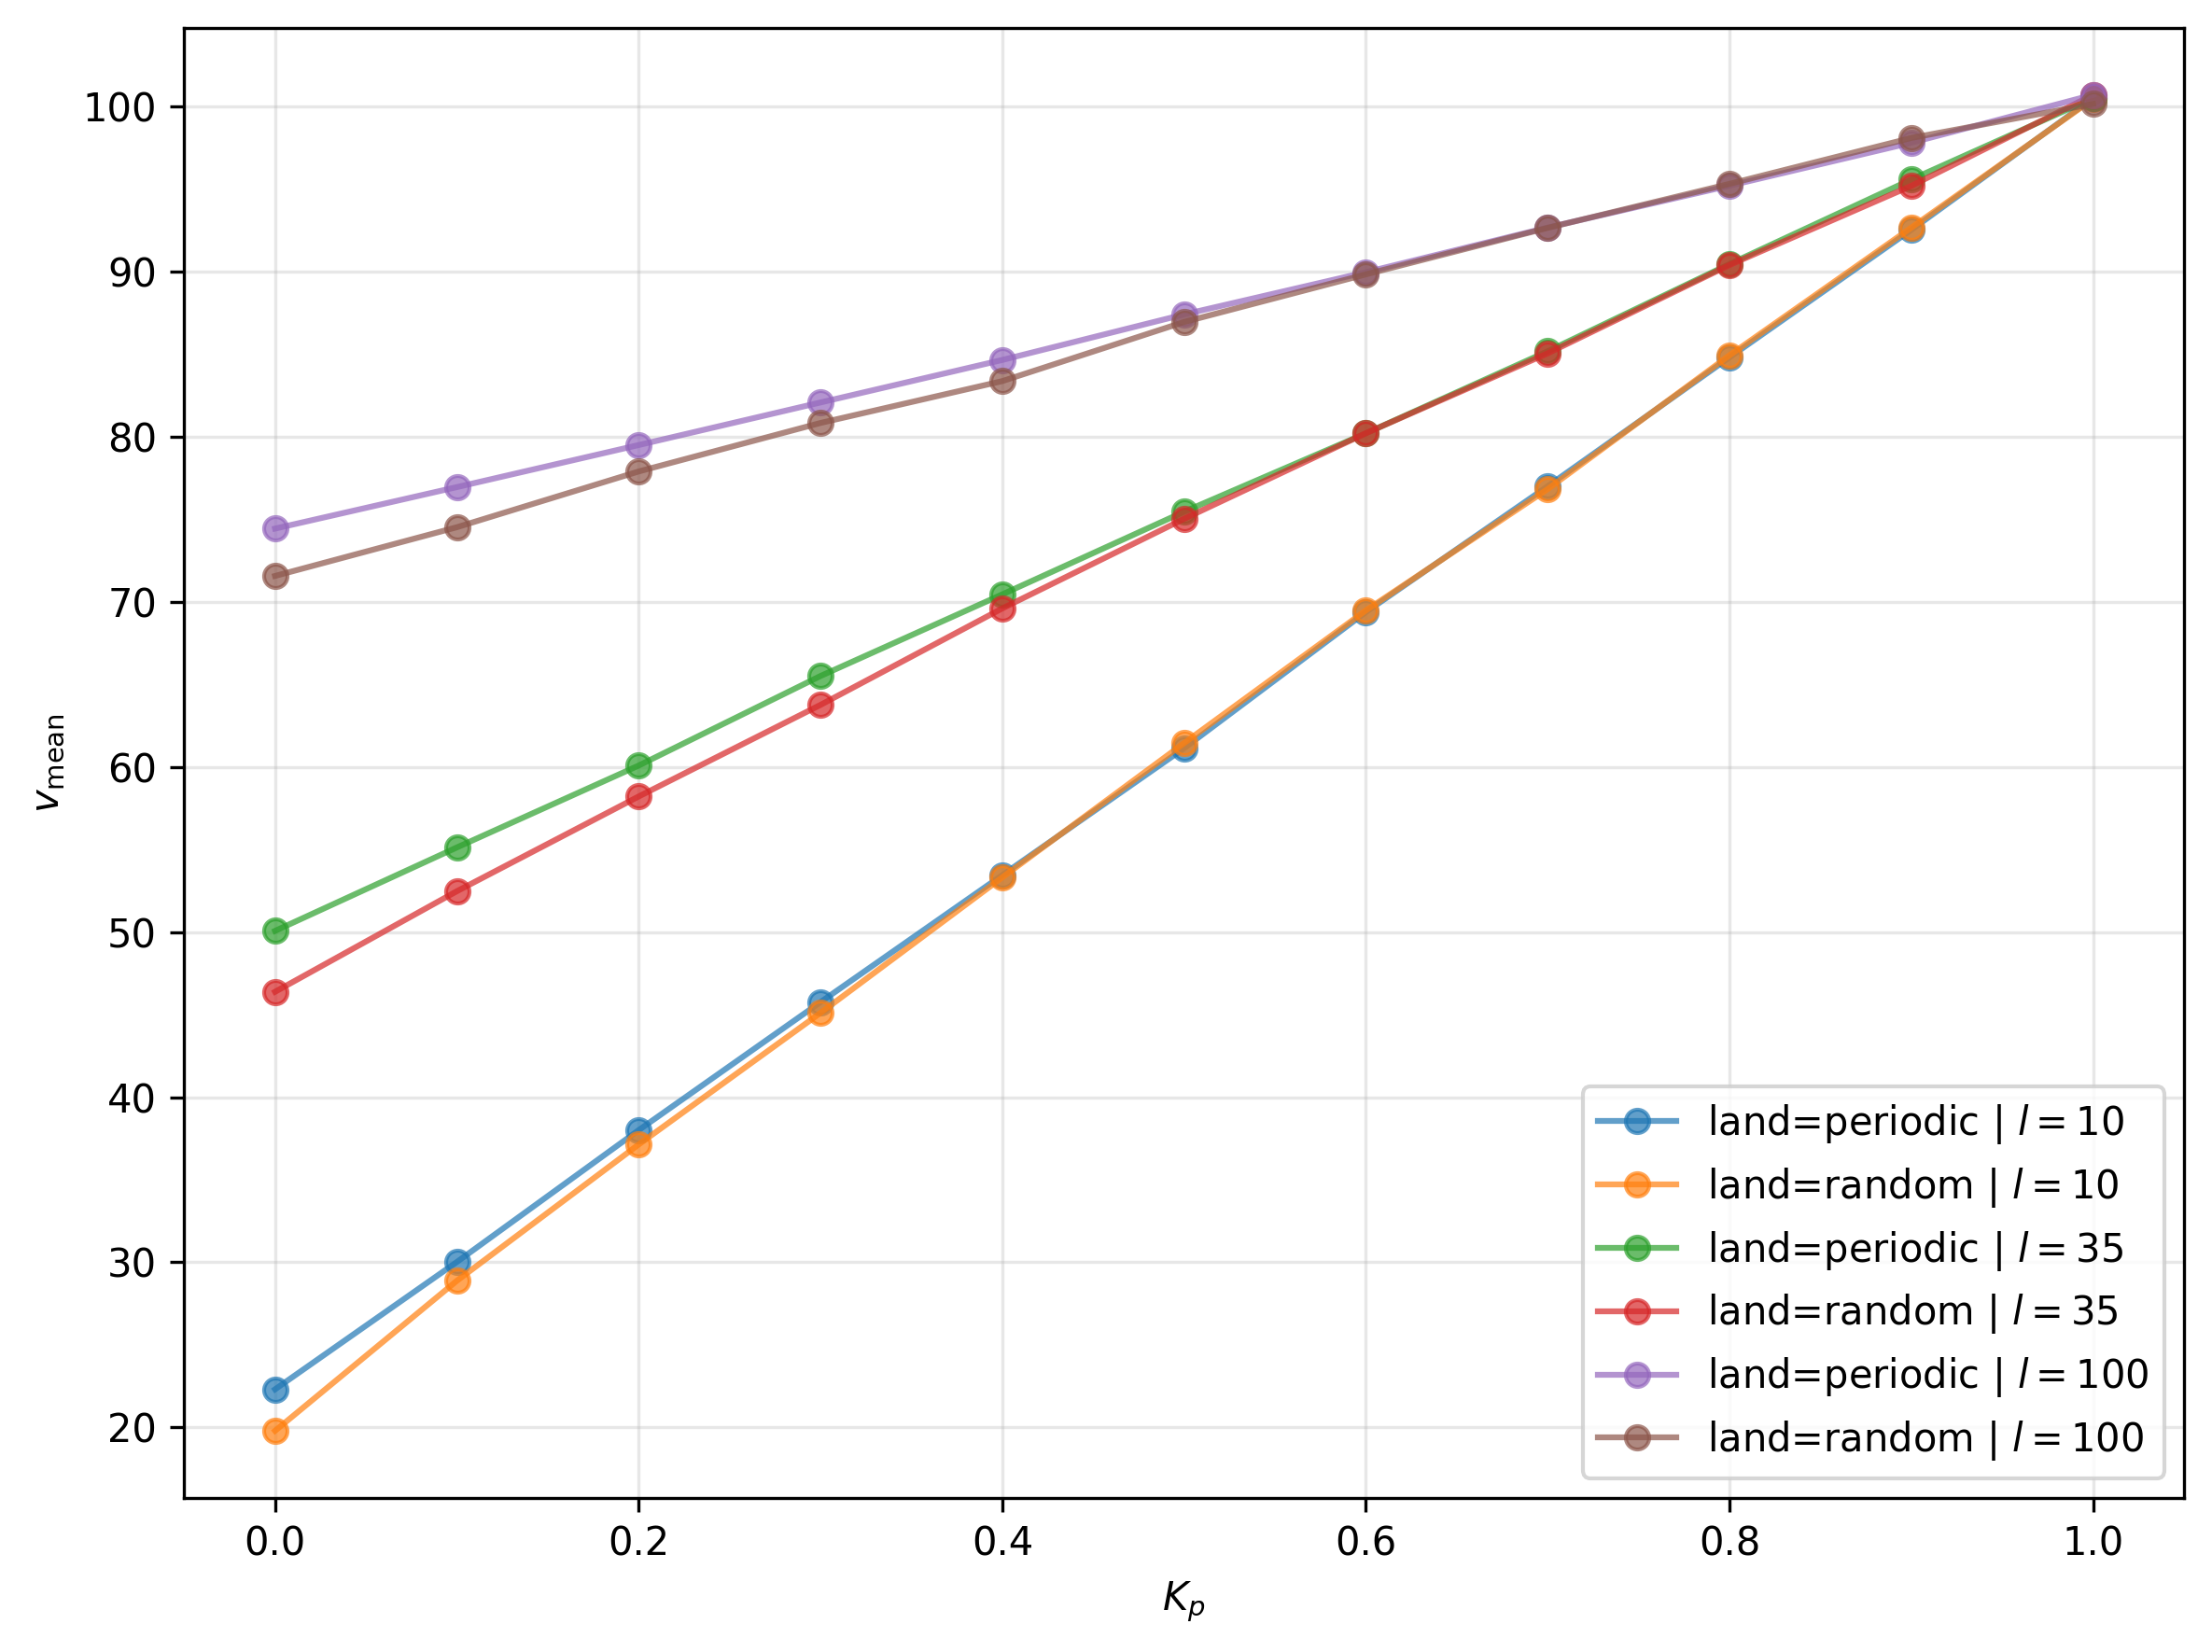

In [ ]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

# Nouvelle colonne Kp * alphar
df_passive = df_passive.with_columns(
    (pl.col("Kp") * pl.col("alphar")).alias("Kpalphar")
)

# Paramètres qui définissent une même condition
param_cols = [
    col for col in df_passive.columns
    if col not in ["v_mean", "Kpalphar"]
]

# Moyenne des valeurs pour les mêmes paramètres
df_passive = (
    df_passive
    .group_by(param_cols)
    .agg(
        pl.col("v_mean").mean().alias("v_mean")
    )
    .sort(["Kp", "alphar"])
)

# - Plot -----
plt.figure(figsize=(8, 6), dpi=300)

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in lands:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l) &
            (pl.col("Kp") == 1)
        )

        plt.plot(
            df_land["alphar"].to_numpy(),
            df_land["v_mean"].to_numpy(),
            marker="o",
            label=f"land={land} | $l={l}$",
            alpha=0.70
        )

plt.xlabel(r"$\alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()


# - Plot -----
plt.figure(figsize=(8, 6), dpi=300)

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in lands:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l) &
            (pl.col("alphar") == 1)
        )

        plt.plot(
            df_land["Kp"].to_numpy(),
            df_land["v_mean"].to_numpy(),
            marker="o",
            label=f"land={land} | $l={l}$",
            alpha=0.70
        )

plt.xlabel(r"$K_p$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

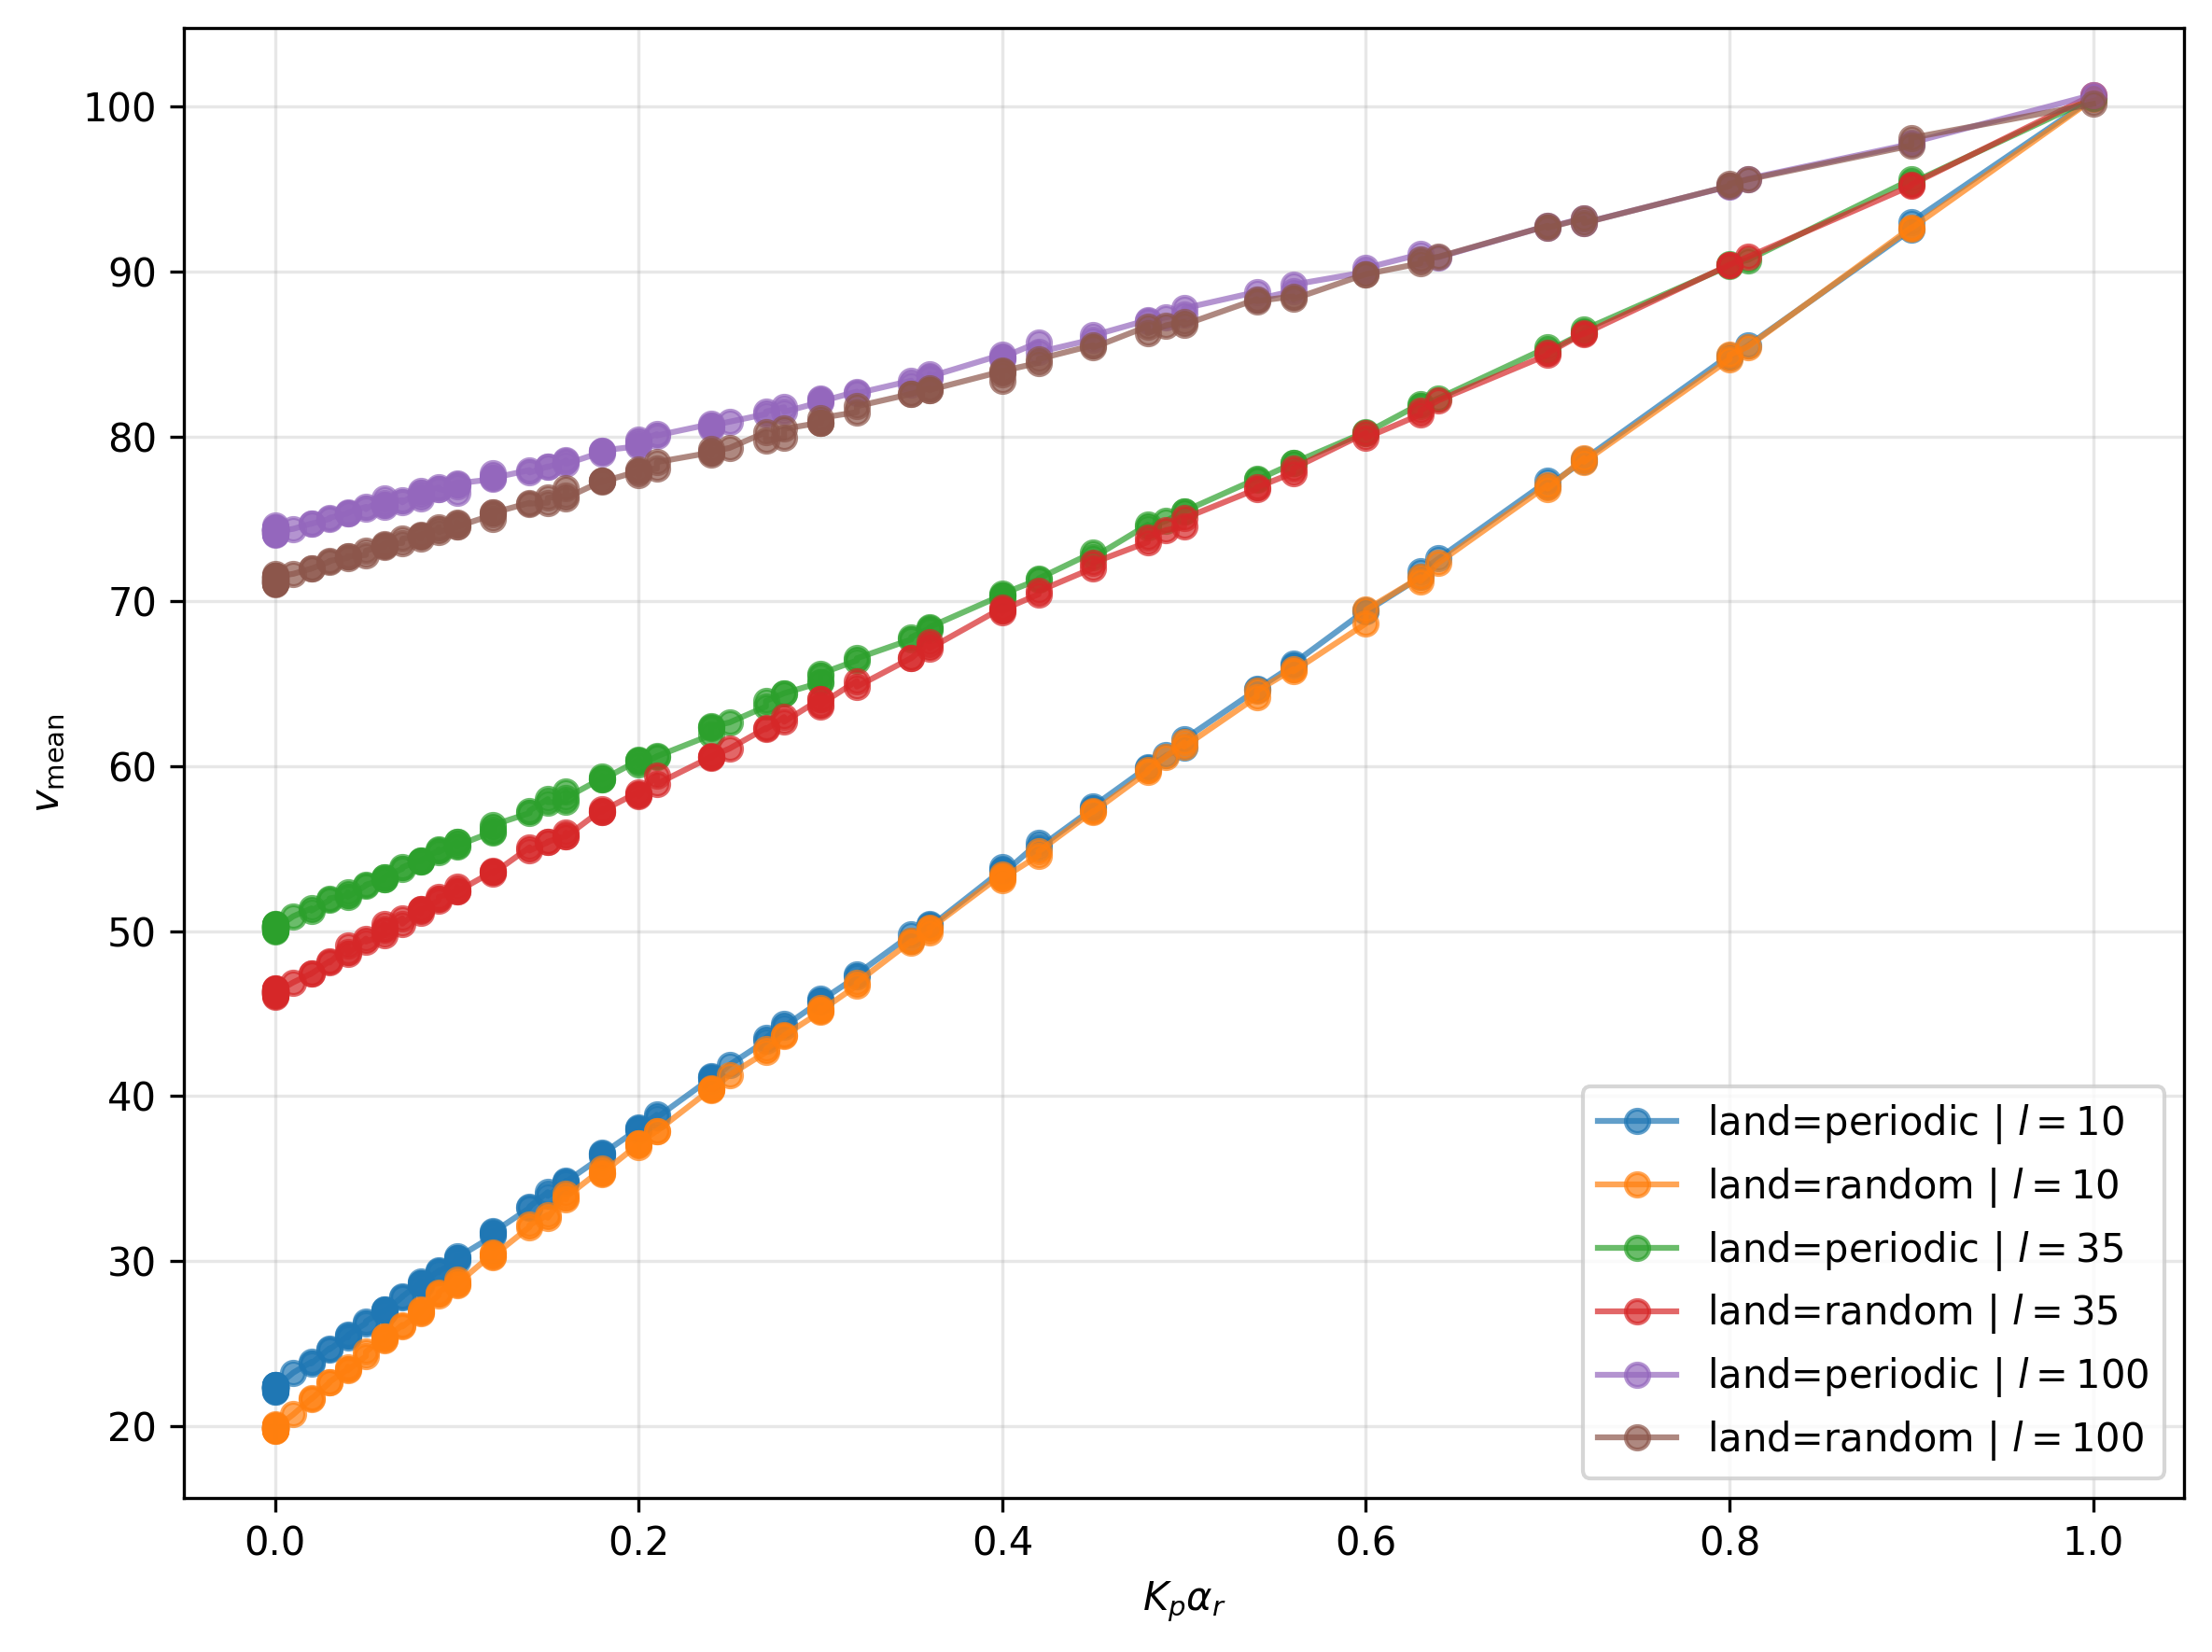

In [ ]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

# Nouvelle colonne Kp * alphar
df_passive = df_passive.with_columns(
    (pl.col("Kp") * pl.col("alphar")).alias("Kpalphar")
)

# Paramètres qui définissent une même condition
param_cols = [
    col for col in df_passive.columns
    if col not in ["v_mean", "Kpalphar"]
]

# Moyenne des valeurs pour les mêmes paramètres
df_passive = (
    df_passive
    .group_by(param_cols)
    .agg(
        pl.col("v_mean").mean().alias("v_mean")
    )
    .with_columns(
        (pl.col("Kp") * pl.col("alphar")).alias("Kpalphar")
    )
    .sort("Kpalphar")
)

# - Plot -----
plt.figure(figsize=(8, 6), dpi=300)

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in lands:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        plt.plot(
            df_land["Kpalphar"].to_numpy(),
            df_land["v_mean"].to_numpy(),
            marker="o",
            label=f"land={land} | $l={l}$",
            alpha=0.70
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
150 * (10/45) * 0.67

22.333333333333332

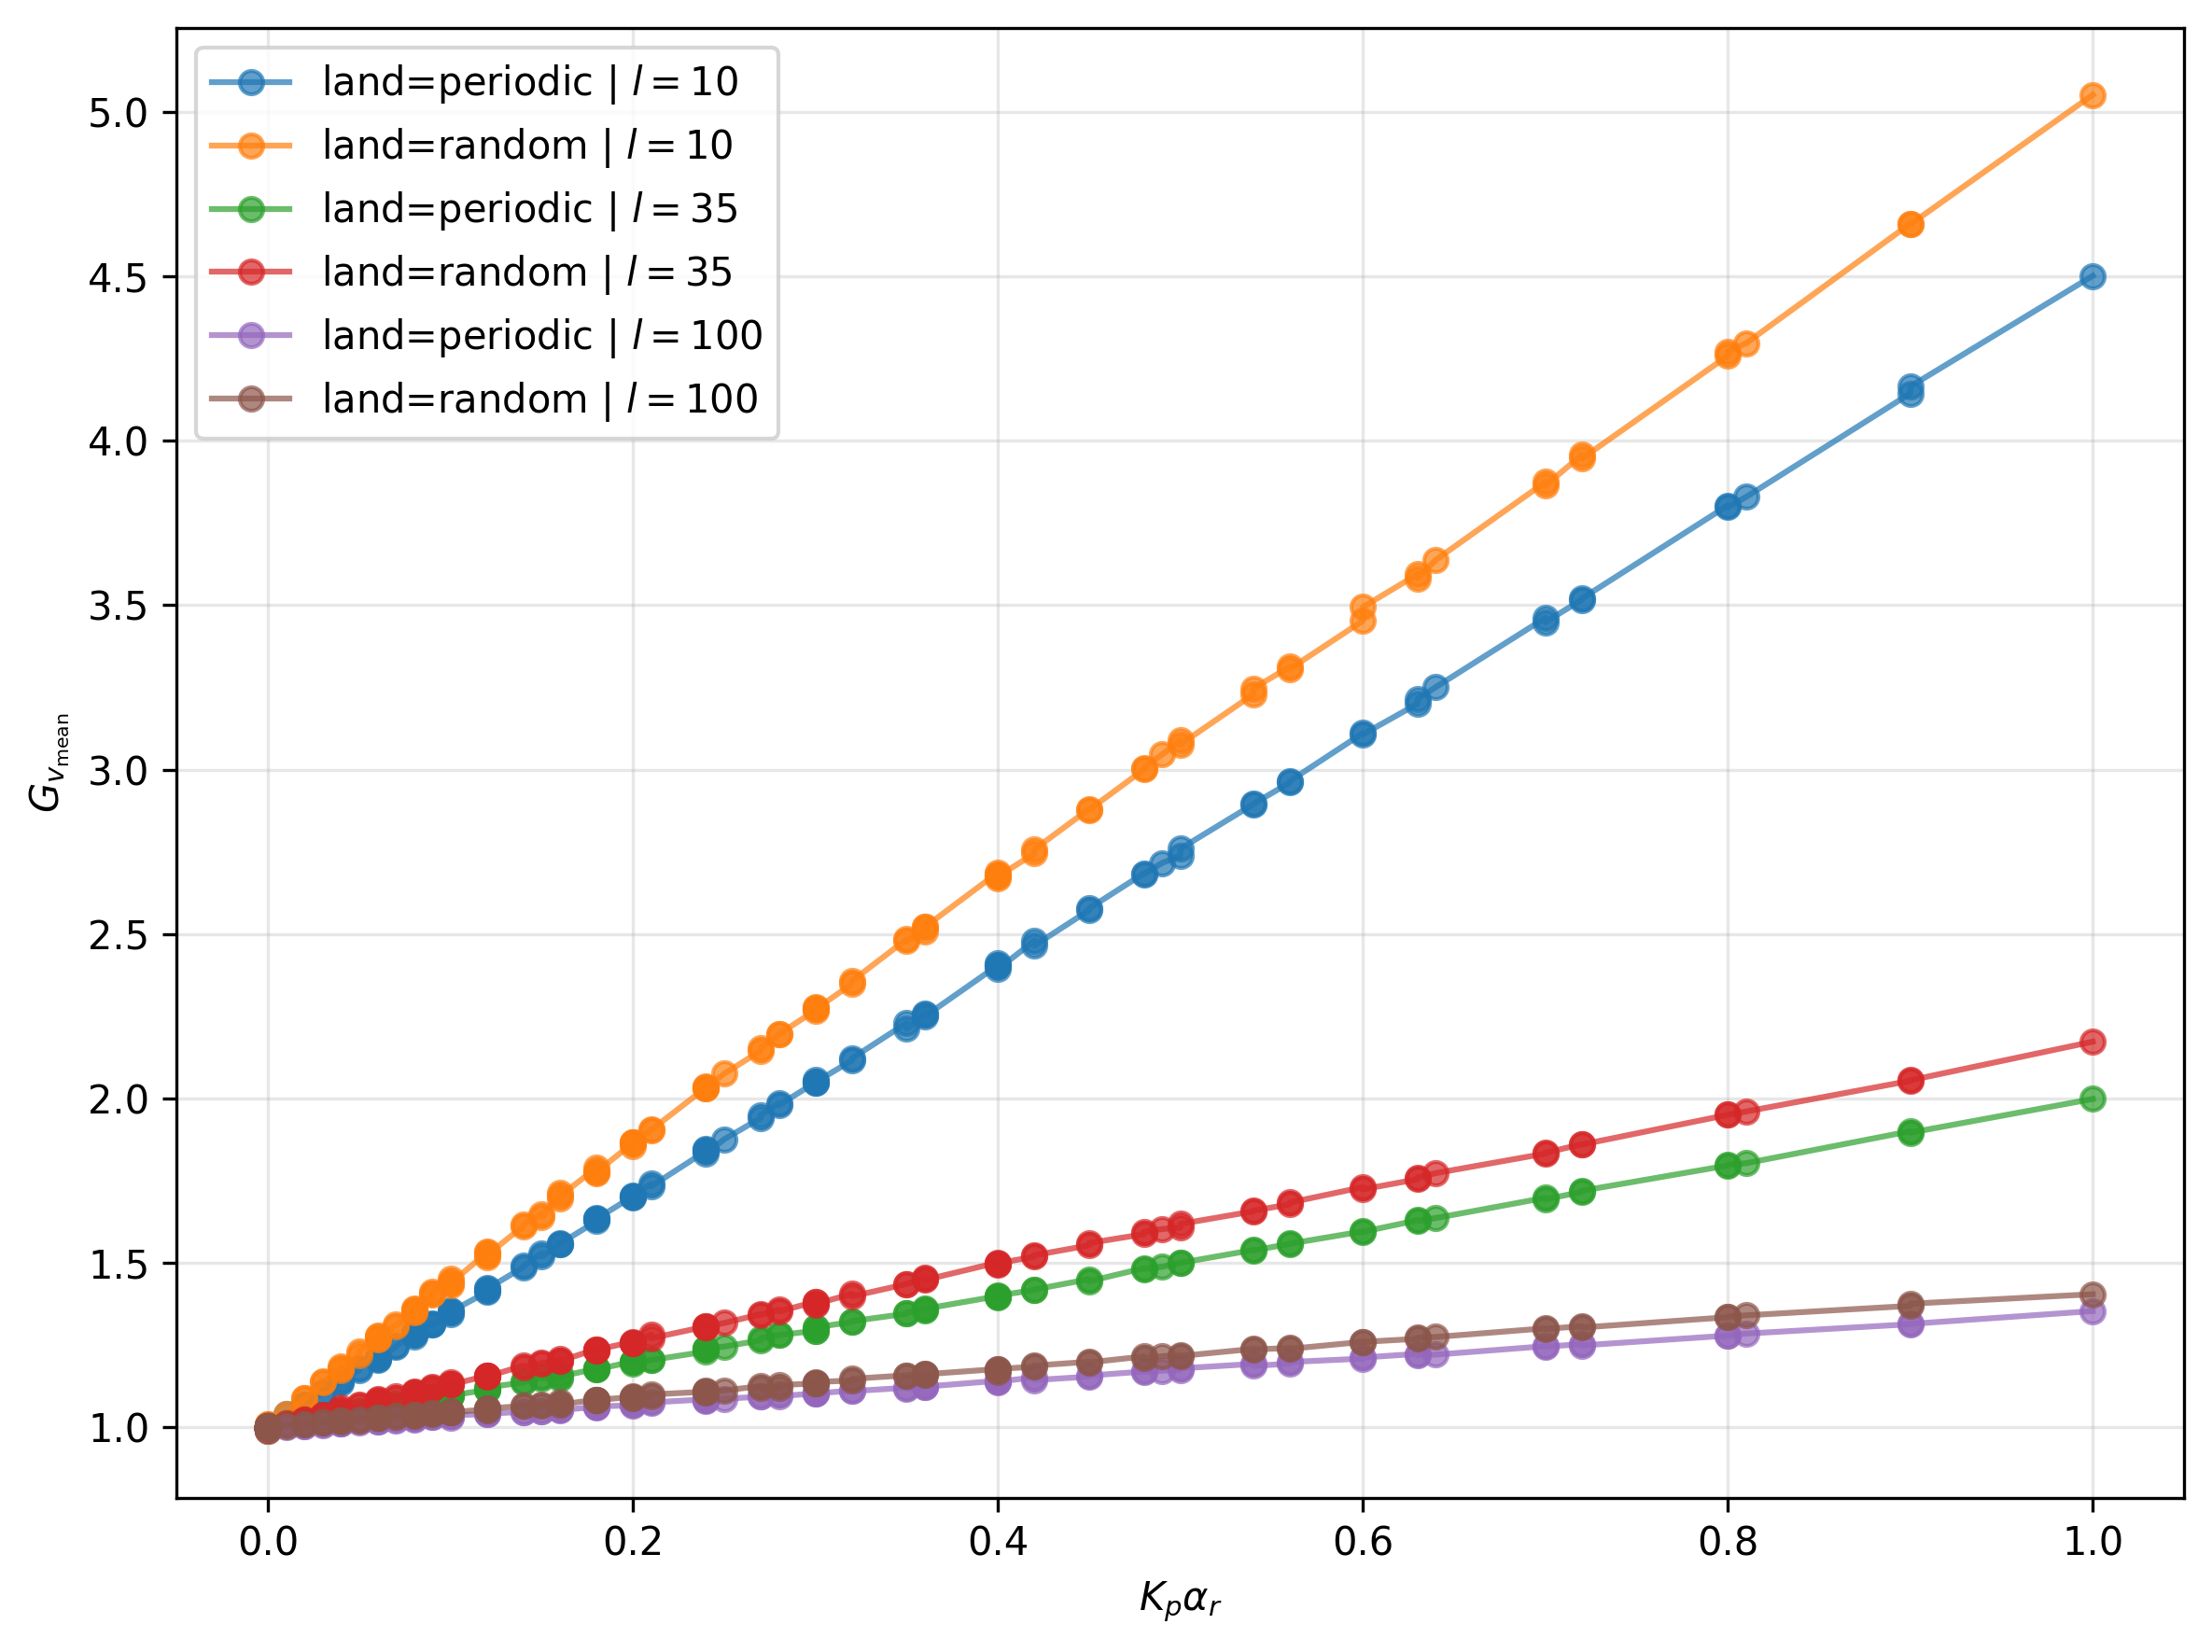

In [ ]:
plt.figure(figsize=(8, 6), dpi=300)

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in lands:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        v_base = df_passive.filter(
            (pl.col("alphar") == 0) &
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )["v_mean"].to_numpy()[0]

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        gain = df_land["v_mean"].to_numpy() / v_base

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            gain[order],
            marker="o",
            label=f"land={land} | $l={l}$",
            alpha=0.70
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$G_{v_{\mathrm{mean}}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

# Passive : bp

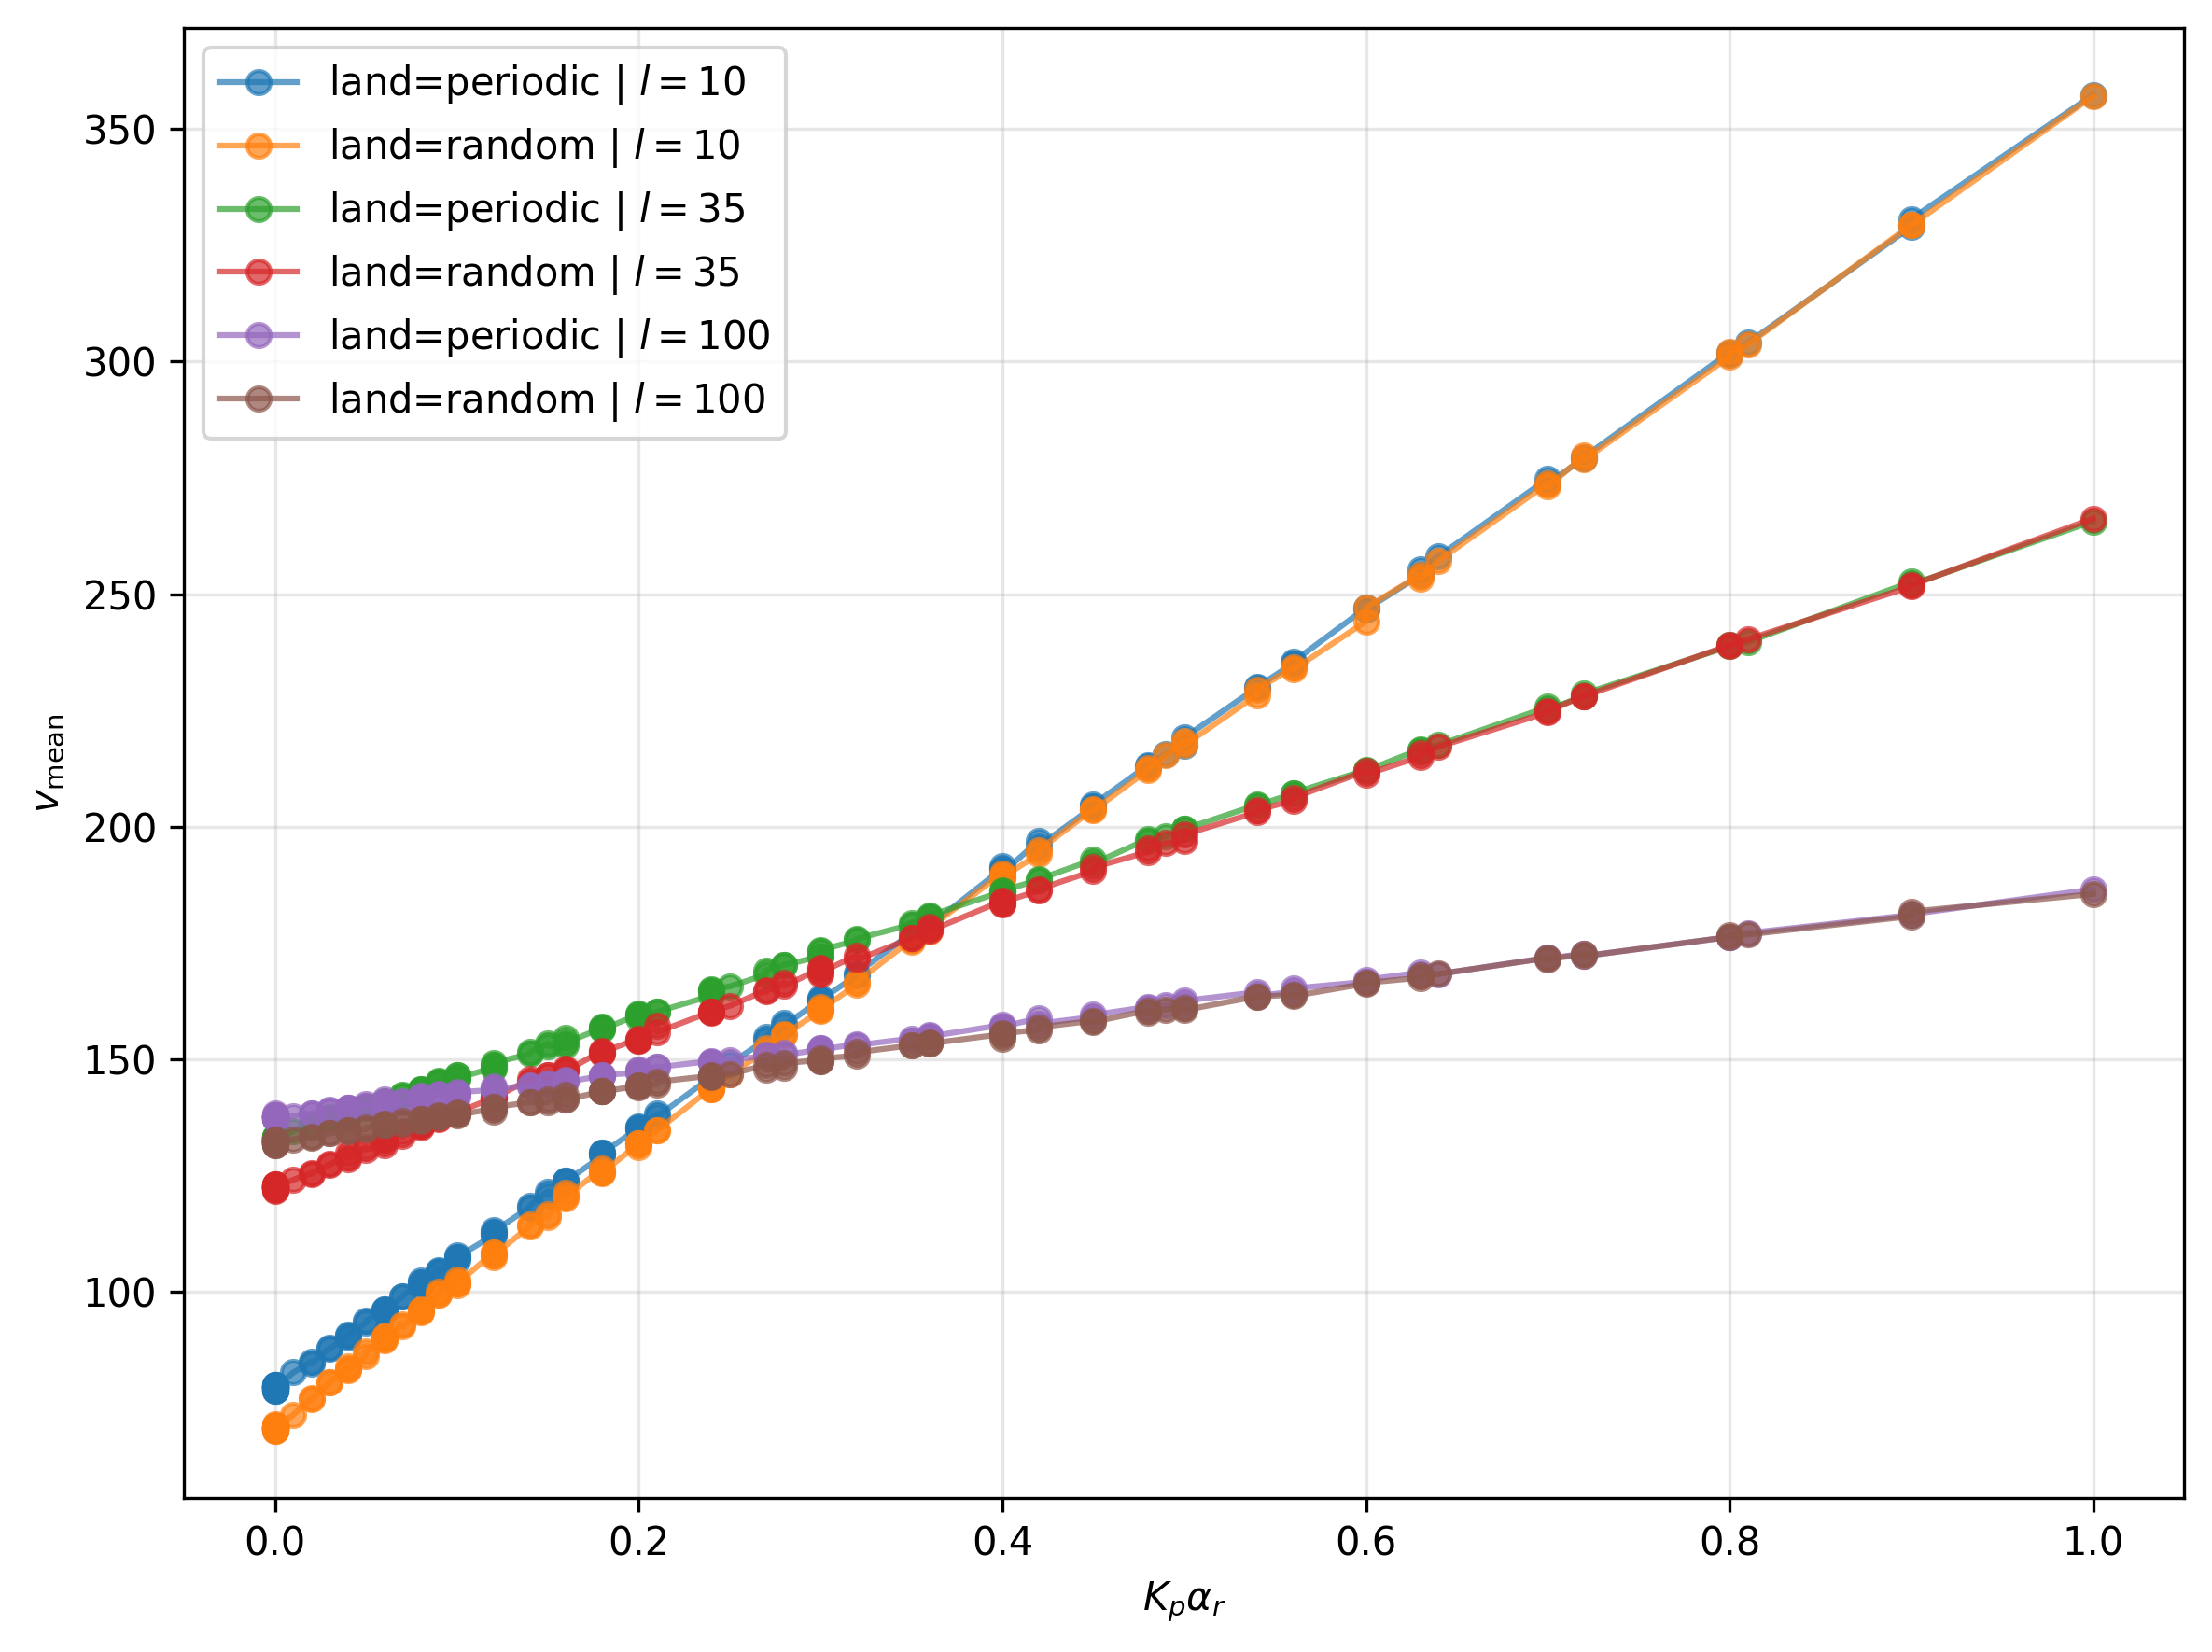

In [ ]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

plt.figure(figsize=(8, 6), dpi=300)

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in lands:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        v_mean_land = df_land["vc_mean"].to_numpy()

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            v_mean_land[order],
            marker="o",
            label=f"land={land} | $l={l}$",
            alpha=0.70
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
150 * 160/45 * 0.67

357.33333333333337

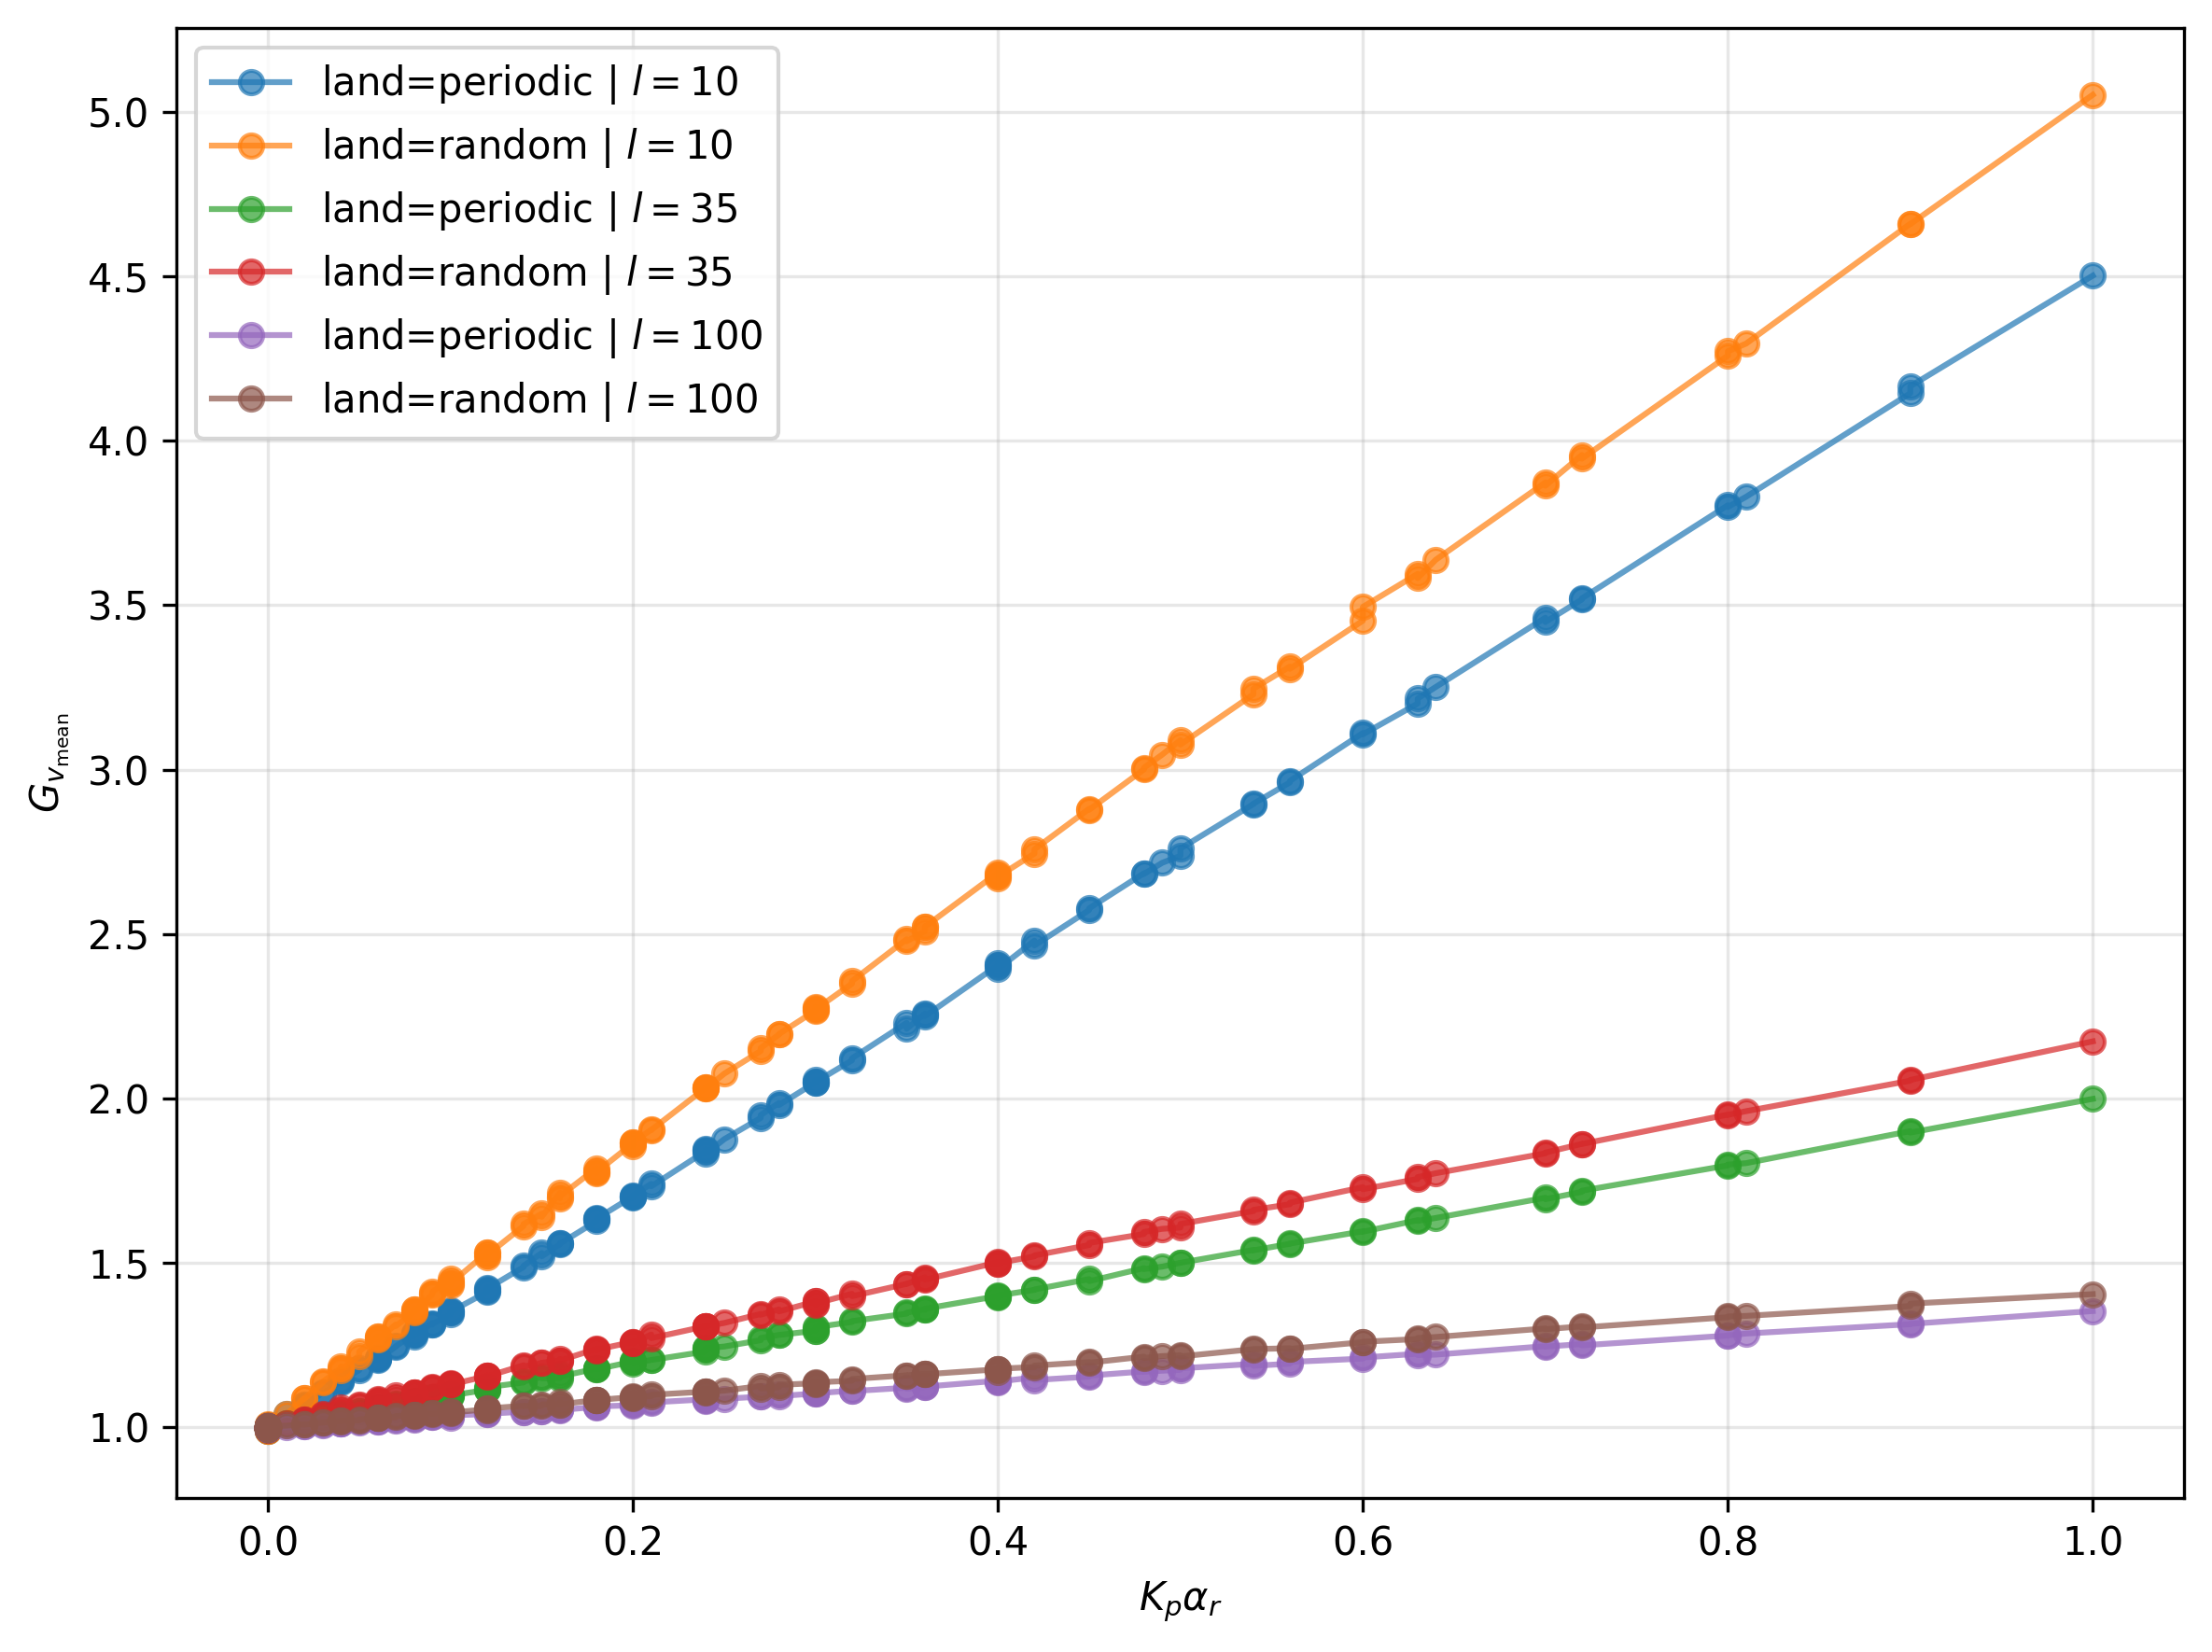

In [ ]:
plt.figure(figsize=(8, 6), dpi=300)

ls      = np.unique(df_passive["l"].to_numpy())
s       = np.unique(df_passive["s"].to_numpy())
mu      = np.unique(df_passive["mu"].to_numpy())
theta   = np.unique(df_passive["theta"].to_numpy())

for l in ls:

    c = (150 + l) / (35 + l)

    for land in lands:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        v_base_c = df_passive.filter(
            (pl.col("alphar") == 0) &
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )["v_mean"].to_numpy()[0] * c

        v_mean_c = df_land["vc_mean"].to_numpy() 

        gain =  v_mean_c / v_base_c

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            gain[order],
            marker="o",
            label=f"land={land} | $l={l}$",
            alpha=0.70
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$G_{v_{\mathrm{mean}}}$")
plt.grid(True, alpha=0.30)
plt.legend()
# plt.loglog(True)
plt.tight_layout()
plt.show()

# Active no mémo

In [1]:
# - Librairies -----
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from nucleo.io.reading import reading_all_parquet


# - Getting the data -----
# root_fact = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-05-21"
# root_fact = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-09-17"
root_fact = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__ACTIVE"
df_fact = reading_all_parquet(root_fact)
COLUMNS = [
    'algo', 'fact', 'mode', 'dstr', 
    'land', 's', 'l', 'bpmin', 
    'mu', 'theta', 'alphaf', 
    'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 
    'alphar', 'krel', 'Kp', 'Kz'
]


# Colonnes numériques qui ne sont PAS des paramètres
VALUE_COLUMNS = [
    col for col in df_fact.columns
    if col not in COLUMNS
    and df_fact.schema[col].is_numeric()
]

df_fact = (
    df_fact
    .group_by(COLUMNS)
    .agg([
        pl.col(col).mean().alias(col)
        for col in VALUE_COLUMNS
    ])
    .sort(COLUMNS)
)

print(df_fact)


# - MODES -----

df_actifull = df_fact.filter(
    pl.col("mode") == "actifull"
)

df_actimemo = df_fact.filter(
    pl.col("mode") == "actimemo"
)

print(df_actifull.shape, df_actimemo.shape)

/home/nicolas/Documents/Workspace/nucleo/src/nucleo/io/reading.py:143: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  cols = _scalar_column_names(lf.schema)


shape: (9_504, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ f64      ┆ f64      ┆ f64   │
╞══════╪══════╪══════════╪═══════╪═══╪═══════╪══════════╪══════════╪═══════╡
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 90.5  ┆ 0.994139 ┆ 0.833906 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 90.5  ┆ 0.998114 ┆ 0.838453 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 90.5  ┆ 0.995398 ┆ 0.835491 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 90.5  ┆ 0.997757 ┆ 0.837107 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 90.5  ┆ 0.999964 ┆ 0.840377 ┆ 0.5   │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …     ┆ …        ┆ …        ┆ …     │
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ 81.5  ┆ 0.980045 ┆ 0.818434 ┆ 0.5   │
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ 77.5  ┆ 0.985349 ┆

In [2]:
for col in COLUMNS:
    print(f"Unique values of {col} : {np.unique(df_actifull[col])}")

lands = ["periodic", "random"]
df_actifull = df_actifull.filter(
    (pl.col("land").is_in(lands))
)


Unique values of algo : ['2S']
Unique values of fact : [ True]
Unique values of mode : ['actifull']
Unique values of dstr : [False]
Unique values of land : ['periodic' 'random']
Unique values of s : [35]
Unique values of l : [ 10  35 100]
Unique values of bpmin : [0]
Unique values of mu : [150]
Unique values of theta : [100]
Unique values of alphaf : [1.]
Unique values of alphao : [0.]
Unique values of beta : [0.]
Unique values of rcapt : [2.]
Unique values of rrest : [2.]
Unique values of alphac : [0.67]
Unique values of alphad : [0.]
Unique values of alphar : [0.  0.2 0.4 0.6 0.8 1. ]
Unique values of krel : [ 0.1         0.46415888  2.15443469 10.        ]
Unique values of Kp : [ 1.          3.16227766 10.        ]
Unique values of Kz : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


Unique values of algo : ['2S']
Unique values of fact : [ True]
Unique values of mode : ['actifull']
Unique values of dstr : [False]
Unique values of land : ['periodic' 'random']
Unique values of s : [35]
Unique values of l : [ 10  35 100]
Unique values of bpmin : [0]
Unique values of mu : [150]
Unique values of theta : [100]
Unique values of alphaf : [1.]
Unique values of alphao : [0.]
Unique values of beta : [0.]
Unique values of rcapt : [2.]
Unique values of rrest : [2.]
Unique values of alphac : [0.67]
Unique values of alphad : [0.]
Unique values of alphar : [0.  0.2 0.4 0.6 0.8 1. ]
Unique values of krel : [ 0.1         0.46415888  2.15443469 10.        ]
Unique values of Kp : [ 1.          3.16227766 10.        ]
Unique values of Kz : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
1
1
1
1
1
1


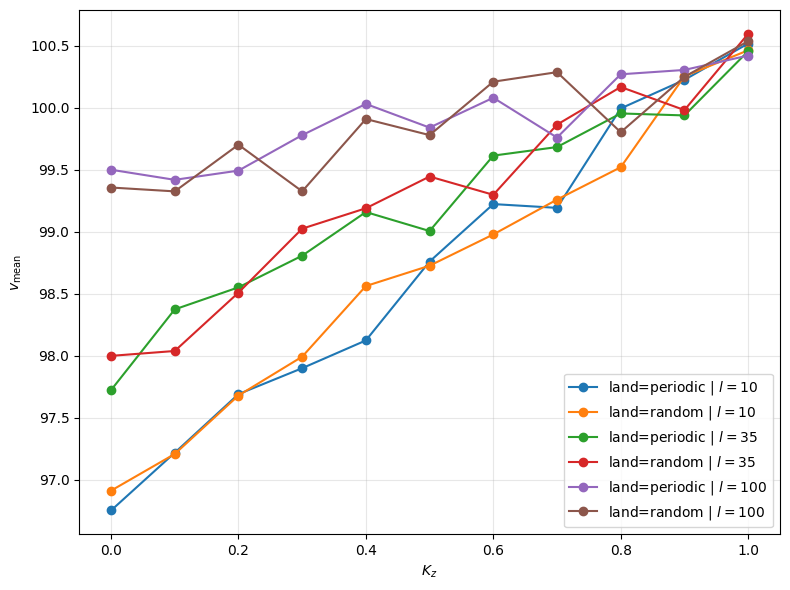

In [12]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np


lands   = np.unique(df_actifull["land"].to_numpy())
ls      = np.unique(df_actifull["l"].to_numpy())
alphar  = 1
Kp      = 1
krel    = 0.1
mu      = 150


plt.figure(figsize=(8, 6), dpi=100)

for col in COLUMNS:
    print(f"Unique values of {col} : {np.unique(df_actifull[col])}")


for l in ls:
    for land in lands:

        df_land = df_actifull.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l) &
            (pl.col("mu") == mu) &
            (pl.col("alphar") == alphar) &
            (pl.col("krel") == krel) &
            (pl.col("Kp") == Kp)
        )

        Kz = df_land["Kz"].to_numpy()
        print(Kp)
        v_mean_land = df_land["v_mean"].to_numpy()

        # order = np.argsort(Kp_alphar)

        plt.plot(
            Kz,
            v_mean_land,
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_z$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

# Active mémo

In [4]:
# - Actifull -----
df_actimemo = df_fact.filter(
    (pl.col("mode") == "actimemo") &
    (pl.col("alphar") == 1)
)

for col in COLUMNS:
    print(f"Unique values of {col} : {np.unique(df_actimemo[col])}")

Unique values of algo : ['2S']
Unique values of fact : [ True]
Unique values of mode : ['actimemo']
Unique values of dstr : [False]
Unique values of land : ['periodic' 'random']
Unique values of s : [35]
Unique values of l : [ 10  35 100]
Unique values of bpmin : [0]
Unique values of mu : [150 300]
Unique values of theta : [100]
Unique values of alphaf : [1.]
Unique values of alphao : [0.]
Unique values of beta : [0.]
Unique values of rcapt : [2.]
Unique values of rrest : [0.1 0.2 2. ]
Unique values of alphac : [0.67]
Unique values of alphad : [0.]
Unique values of alphar : [1.]
Unique values of krel : [1.]
Unique values of Kp : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Unique values of Kz : [0.  0.5 1. ]


Unique values of algo : ['2S']
Unique values of fact : [ True]
Unique values of mode : ['actifull']
Unique values of dstr : [False]
Unique values of land : ['periodic' 'random']
Unique values of s : [35]
Unique values of l : [ 10  35 100]
Unique values of bpmin : [0]
Unique values of mu : [150 300]
Unique values of theta : [100]
Unique values of alphaf : [1.]
Unique values of alphao : [0.]
Unique values of beta : [0.]
Unique values of rcapt : [2.]
Unique values of rrest : [0.1 0.2 2. ]
Unique values of alphac : [0.67]
Unique values of alphad : [0.]
Unique values of alphar : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Unique values of krel : [1.]
Unique values of Kp : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Unique values of Kz : [0.  0.5 1. ]


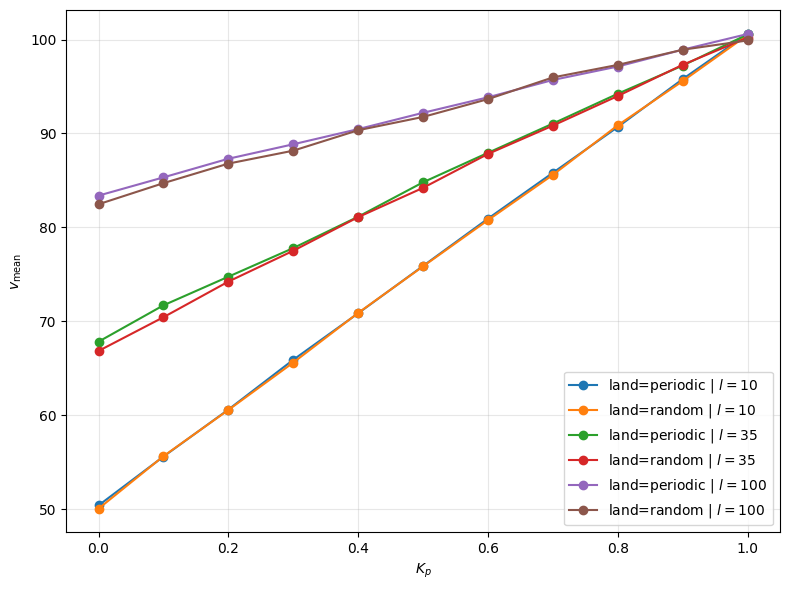

In [8]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np


lands   = np.unique(df_actimemo["land"].to_numpy())
ls      = np.unique(df_actimemo["l"].to_numpy())
Kz      = 1
rrest   = 2.0
mu      = 150


plt.figure(figsize=(8, 6), dpi=100)

for col in COLUMNS:
    print(f"Unique values of {col} : {np.unique(df_actifull[col])}")


for l in ls:
    for land in lands:

        df_land = df_actimemo.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l) &
            (pl.col("mu") == mu) &
            (pl.col("rrest") == rrest) &
            (pl.col("Kz") == Kz)
        )

        Kp = df_land["Kp"].to_numpy()
        v_mean_land = df_land["v_mean"].to_numpy()

        # order = np.argsort(Kp_alphar)

        plt.plot(
            Kp,
            v_mean_land,
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
import numpy as np

test = np.logspace(-1, 1, 10)
print(test)

6 * 11 * 11 * 11 * 10


print(np.logspace(0, 1, 3, dtype=float))

[ 0.1         0.16681005  0.27825594  0.46415888  0.77426368  1.29154967
  2.15443469  3.59381366  5.9948425  10.        ]
[ 1.          3.16227766 10.        ]


In [23]:
alpha_matrix = np.array(
    [0.5,0.5,1,1,0,0],
)

c_linker = 1
c_nucleo = 150/35
compaction = c_linker * alpha_matrix + c_nucleo * (1 - alpha_matrix)
print(compaction)

[2.64285714 2.64285714 1.         1.         4.28571429 4.28571429]


shape: (1, 92)
┌──────┬──────┬──────────┬───────┬───┬────────────────┬────────────────┬───────────┬───────────────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ vi_points      ┆ vi_distrib     ┆ xt_over_t ┆ G             │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---            ┆ ---            ┆ ---       ┆ ---           │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ list[f64]      ┆ list[f64]      ┆ list[f64] ┆ list[f64]     │
╞══════╪══════╪══════════╪═══════╪═══╪════════════════╪════════════════╪═══════════╪═══════════════╡
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ [0.5, 1.5, …   ┆ [0.0, 0.2, …   ┆ [160.8,   ┆ [0.0,         │
│      ┆      ┆          ┆       ┆   ┆ 99999.5]       ┆ 0.0]           ┆ 80.4, …   ┆ -0.016929, …  │
│      ┆      ┆          ┆       ┆   ┆                ┆                ┆ 3.194949] ┆ 3.067969]     │
└──────┴──────┴──────────┴───────┴───┴────────────────┴────────────────┴───────────┴───────────────┘


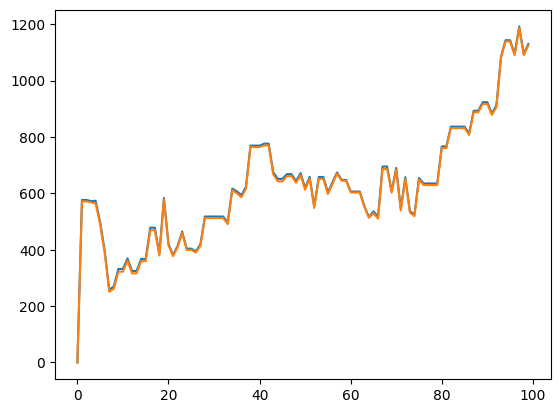

In [47]:
root = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT_ACTIVE_MEMORY__PC__2026-09-22/nucleo__actimemo__0/algo=2S__fact=True__mode=actimemo__dstr=False__land=periodic__s=35__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=1.0e-01__alphac=6.7e-01__alphad=0.0e+00__alphar=0.0e+00__krel=1.0e+00__Kp=6.0e-01__Kz=0.0e+00__nt=1.0e+01__"
df = pl.read_parquet(root)
print(df)

plt.figure()
c_linker = 1
c_nucleo = 150/35
s = 35
l = 10
c = (l * c_linker + s * c_nucleo) / (l+s)

results_mean = df["results_mean"][0].to_numpy()
results_c = df["results_c"][0].to_numpy()


plt.plot(np.mean(results_c, axis=0))
plt.plot(results_mean * c)
plt.show()

# .